<a href="https://colab.research.google.com/github/dariia-64/TRSPO_Fatykova/blob/main/%D0%94%D0%B8%D0%BF%D0%BB%D0%BE%D0%BC%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Налаштування середовища
**Встановлення бібліотек**

In [1]:
!pip install telethon
!pip install emoji
!pip install tqdm
!pip install scikit-learn
!pip install transformers
!pip install datasets
!pip install accelerate -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.6/773.6 kB 12.5 MB/s eta 0:00:00
  Created wheel for pyaes: filename=pyaes-1.6.1-py3-none-any.whl size=26347 sha256=393cdc24e23f5b0e67280215fa7044918898c1a6c7a54f27a6cb03cc76641914
  Stored in directory: /root/.cache/pip/wheels/d9/43/32/ec313dd557e88e419489b9df40c04dad7b99576bde162496f8
Successfully built pyaes
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.2 MB/s eta 0:00:00


**Імпорти**

In [2]:
import os
import re
import json
import random
import warnings
from datetime import datetime
from getpass import getpass

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

warnings.filterwarnings("ignore")

**Фіксація random seed**

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

**Підключення Google Drive**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Структура папок проєкту**

In [5]:
PROJECT_DIR = "/content/drive/MyDrive/telegram_spam_diploma"

DATA_DIR = os.path.join(PROJECT_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

for folder in [PROJECT_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Структура проєкту створена:")
print(PROJECT_DIR)

Структура проєкту створена:
/content/drive/MyDrive/telegram_spam_diploma


**Шляхи до основних файлів**

In [6]:
RAW_MESSAGES_PATH = os.path.join(RAW_DIR, "telegram_messages_raw.csv")
CLEAN_MESSAGES_PATH = os.path.join(PROCESSED_DIR, "telegram_messages_clean.csv")
LABELED_DATA_PATH = os.path.join(PROCESSED_DIR, "telegram_messages_labeled.csv")
FEATURES_DATA_PATH = os.path.join(PROCESSED_DIR, "telegram_messages_features.csv")

MODEL_RESULTS_PATH = os.path.join(RESULTS_DIR, "model_comparison.csv")
ERROR_ANALYSIS_PATH = os.path.join(RESULTS_DIR, "error_analysis.csv")

**Перевірка**

In [7]:
paths = {
    "RAW_MESSAGES_PATH": RAW_MESSAGES_PATH,
    "CLEAN_MESSAGES_PATH": CLEAN_MESSAGES_PATH,
    "LABELED_DATA_PATH": LABELED_DATA_PATH,
    "FEATURES_DATA_PATH": FEATURES_DATA_PATH,
    "MODEL_RESULTS_PATH": MODEL_RESULTS_PATH,
    "ERROR_ANALYSIS_PATH": ERROR_ANALYSIS_PATH
}

for name, path in paths.items():
    print(f"{name}: {path}")

RAW_MESSAGES_PATH: /content/drive/MyDrive/telegram_spam_diploma/data/raw/telegram_messages_raw.csv
CLEAN_MESSAGES_PATH: /content/drive/MyDrive/telegram_spam_diploma/data/processed/telegram_messages_clean.csv
LABELED_DATA_PATH: /content/drive/MyDrive/telegram_spam_diploma/data/processed/telegram_messages_labeled.csv
FEATURES_DATA_PATH: /content/drive/MyDrive/telegram_spam_diploma/data/processed/telegram_messages_features.csv
MODEL_RESULTS_PATH: /content/drive/MyDrive/telegram_spam_diploma/results/model_comparison.csv
ERROR_ANALYSIS_PATH: /content/drive/MyDrive/telegram_spam_diploma/results/error_analysis.csv


##Збір повідомлень з Telegram
**Імпорт Telethon**

In [8]:
from telethon import TelegramClient
from telethon.errors import FloodWaitError, ChannelInvalidError, ChannelPrivateError

**Введення API-даних**

In [9]:
API_ID = 32505723
API_HASH = "b0b4fa07e1a1e38d3533c7300096a078"
PHONE = "+380667879099"

**Список Telegram-каналів**

In [10]:
CHANNELS = {
    "news": [
        "kievinfo_kyiv",
        "truexanewsua"
    ],
    "university": [
        "dekanat_ipsa"
    ],
    "crypto_finance": [
        "incrypted_UA",
        "Easy_Moneyyyyyyyyyyy"
    ],
    "books_content": [
        "ksd_bookclub"
    ],
    "casino": [
        "Parik24_Betking"
    ]
}

LIMIT_PER_CHANNEL = 700

**Перетворення списку каналів у таблицю джерел**

In [11]:
channel_rows = []

for category, channels in CHANNELS.items():
    for channel in channels:
        channel_rows.append({
            "source": channel,
            "source_category": category
        })

channels_df = pd.DataFrame(channel_rows)
channels_df

,source,source_category
0,kievinfo_kyiv,news
1,truexanewsua,news
2,dekanat_ipsa,university
3,incrypted_UA,crypto_finance
4,Easy_Moneyyyyyyyyyyy,crypto_finance
5,ksd_bookclub,books_content
6,Parik24_Betking,casino


**Функція збору повідомлень**

In [12]:
async def collect_telegram_messages(
    api_id,
    api_hash,
    phone,
    channels_df,
    limit_per_channel=500
):
    """
    Збирає повідомлення з відкритих Telegram-каналів.

    Повертає DataFrame з текстом повідомлення та метаданими,
    які надалі можуть бути використані для побудови ознак.
    """

    SESSION_PATH = "/content/drive/MyDrive/telegram_spam_diploma/telegram_spam_session"
    client = TelegramClient(SESSION_PATH, api_id, api_hash)
    await client.start(phone=phone)

    all_messages = []
    collection_log = []

    for _, row in channels_df.iterrows():
        channel = row["source"]
        source_category = row["source_category"]

        print(f"\nЗбір повідомлень з каналу: {channel}")

        try:
            entity = await client.get_entity(channel)

            collected_count = 0
            skipped_empty_count = 0

            async for message in client.iter_messages(entity, limit=limit_per_channel):
                if message.text is None or len(message.text.strip()) == 0:
                    skipped_empty_count += 1
                    continue

                text = message.text.strip()

                all_messages.append({
                    "message_id": message.id,
                    "source": channel,
                    "source_category": source_category,
                    "text": text,
                    "date": message.date,
                    "views": message.views if message.views is not None else 0,
                    "forwards": message.forwards if message.forwards is not None else 0,
                    "has_media": int(message.media is not None),
                    "message_length": len(text)
                })

                collected_count += 1

            collection_log.append({
                "source": channel,
                "source_category": source_category,
                "status": "success",
                "collected_count": collected_count,
                "skipped_empty_count": skipped_empty_count,
                "error": None
            })

            print(f"Зібрано текстових повідомлень: {collected_count}")

        except FloodWaitError as e:
            error_text = f"FloodWaitError: потрібно зачекати {e.seconds} секунд"
            print(error_text)

            collection_log.append({
                "source": channel,
                "source_category": source_category,
                "status": "flood_wait",
                "collected_count": 0,
                "skipped_empty_count": 0,
                "error": error_text
            })

        except (ChannelInvalidError, ChannelPrivateError) as e:
            error_text = f"Канал недоступний або приватний: {e}"
            print(error_text)

            collection_log.append({
                "source": channel,
                "source_category": source_category,
                "status": "unavailable",
                "collected_count": 0,
                "skipped_empty_count": 0,
                "error": error_text
            })

        except Exception as e:
            error_text = str(e)
            print(f"Помилка для каналу {channel}: {error_text}")

            collection_log.append({
                "source": channel,
                "source_category": source_category,
                "status": "error",
                "collected_count": 0,
                "skipped_empty_count": 0,
                "error": error_text
            })

    await client.disconnect()

    messages_df = pd.DataFrame(all_messages)
    log_df = pd.DataFrame(collection_log)

    return messages_df, log_df

**Запуск збору даних**

In [13]:
df_raw, collection_log_df = await collect_telegram_messages(
    api_id=API_ID,
    api_hash=API_HASH,
    phone=PHONE,
    channels_df=channels_df,
    limit_per_channel=LIMIT_PER_CHANNEL
)


Збір повідомлень з каналу: kievinfo_kyiv
Зібрано текстових повідомлень: 508

Збір повідомлень з каналу: truexanewsua
Зібрано текстових повідомлень: 540

Збір повідомлень з каналу: dekanat_ipsa
Зібрано текстових повідомлень: 511

Збір повідомлень з каналу: incrypted_UA
Зібрано текстових повідомлень: 667

Збір повідомлень з каналу: Easy_Moneyyyyyyyyyyy
Зібрано текстових повідомлень: 281

Збір повідомлень з каналу: ksd_bookclub


Зібрано текстових повідомлень: 380

Збір повідомлень з каналу: Parik24_Betking
Зібрано текстових повідомлень: 468


**Перевірка зібраних даних**

In [14]:
print("Загальна кількість зібраних повідомлень:", len(df_raw))

df_raw.head()

Загальна кількість зібраних повідомлень: 3355


,message_id,source,source_category,text,date,views,forwards,has_media,message_length
0,89867,kievinfo_kyiv,news,🛴❌Планують конфіскувати електросамокати в укра...,2026-06-02 11:43:29+00:00,103288,927,0,481
1,89866,kievinfo_kyiv,news,"**У Києві скандал. Причина — **[**намети 🏕️ , ...",2026-06-02 10:54:51+00:00,182276,1544,1,499
2,89857,kievinfo_kyiv,news,Ось такий стовп ДИМУ 💥 Видно після падіння БПЛ...,2026-06-02 10:30:12+00:00,209481,921,1,249
3,89856,kievinfo_kyiv,news,**✅ВІДБІЙ ПОВІТРЯНОЇ ТРИВОГИ ✅**,2026-06-02 10:27:53+00:00,195385,34,0,32
4,89855,kievinfo_kyiv,news,Видно дим в центрі міста. Наразі не відомо чи ...,2026-06-02 10:22:59+00:00,220570,649,0,298


**Лог збору даних**

In [15]:
collection_log_df

,source,source_category,status,collected_count,skipped_empty_count,error
0,kievinfo_kyiv,news,success,508,192,None
1,truexanewsua,news,success,540,160,None
2,dekanat_ipsa,university,success,511,189,None
3,incrypted_UA,crypto_finance,success,667,33,None
4,Easy_Moneyyyyyyyyyyy,crypto_finance,success,281,50,None
5,ksd_bookclub,books_content,success,380,320,None
6,Parik24_Betking,casino,success,468,108,None


In [16]:
COLLECTION_LOG_PATH = os.path.join(RAW_DIR, "telegram_collection_log.csv")

collection_log_df.to_csv(
    COLLECTION_LOG_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Лог збору збережено:")
print(COLLECTION_LOG_PATH)

Лог збору збережено:
/content/drive/MyDrive/telegram_spam_diploma/data/raw/telegram_collection_log.csv


**Кількість повідомлень по каналах**

In [17]:
df_raw["source"].value_counts()

,count
source,
incrypted_UA,667
truexanewsua,540
dekanat_ipsa,511
kievinfo_kyiv,508
Parik24_Betking,468
ksd_bookclub,380
Easy_Moneyyyyyyyyyyy,281


**Кількість повідомлень по категоріях джерел**

In [18]:
df_raw["source_category"].value_counts()

,count
source_category,
news,1048
crypto_finance,948
university,511
casino,468
books_content,380


**Збереження сирого датасету**

In [19]:
df_raw.to_csv(
    RAW_MESSAGES_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Сирий датасет збережено:")
print(RAW_MESSAGES_PATH)

Сирий датасет збережено:
/content/drive/MyDrive/telegram_spam_diploma/data/raw/telegram_messages_raw.csv


**Первинна перевірка якості датасету**

In [20]:
print("Розмір датасету:", df_raw.shape)

print("\nКількість пропусків:")
print(df_raw.isna().sum())

print("\nКількість дублікатів тексту:")
print(df_raw.duplicated(subset=["text"]).sum())

Розмір датасету: (3355, 9)

Кількість пропусків:
message_id         0
source             0
source_category    0
text               0
date               0
views              0
forwards           0
has_media          0
message_length     0
dtype: int64

Кількість дублікатів тексту:
291


**Перегляд прикладів повідомлень**

In [21]:
pd.set_option("display.max_colwidth", 200)

df_raw[["source", "source_category", "text", "date", "views", "forwards", "has_media"]].sample(
    10,
    random_state=SEED
)

,source,source_category,text,date,views,forwards,has_media
3250,Parik24_Betking,casino,Вдячний!,2026-03-22 08:22:40+00:00,0,0,0
596,truexanewsua,news,**😐****Google готується випустити 32 млн **[**заражених**](https://nypost.com/2026/05/29/us-news/google-planning-to-release-millions-of-mosquitoes-into-california-to-help-stop-diseases/)** бактері...,2026-06-01 07:40:10+00:00,673023,2104,1
2236,Easy_Moneyyyyyyyyyyy,crypto_finance,"🎉 **Вітаю всіх з прийдешнім Новим роком!****🍬****🎩****\n\n**🤑**Нехай 2025 рік буде успішним та прибутковим для кожного з нас. Бажаю кожному з вас здоровʼя, миру, зростання вашого крипто-портфелю а...",2024-12-31 17:00:03+00:00,2353,0,1
1064,dekanat_ipsa,university,"Любиш працювати з цифрами та аналізувати інформацію? Це метч 😍 \nТи знайшов для себе класний івент, а ми ідеального кандидата/ку.\n\nCommodity Trading Experience 2.0 від LDC – подію для студентів ...",2026-05-22 16:00:52+00:00,1006,6,1
315,kievinfo_kyiv,news,**Станція метро Лукʼянівка сьогодні зранку 🤯 **\n[ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi)\n**Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot\n🇺🇦 ➡️ [**ПІДПИСАТИСЬ**](https://t.me/+aAaZ8kQkkpo2Z...,2026-05-24 13:39:21+00:00,359374,2502,1
1735,incrypted_UA,crypto_finance,**🇵🇱 Польща схвалила закон про регулювання крипторинку відповідно до MiCA**\n\nПарламент Польщі [підтримав](https://incrypted.com/ua/polshcha-uhvalyla-zakon-pro-reguljuvannja-kryptorynku-na-tli-ro...,2026-05-15 15:50:08+00:00,853,5,1
2739,ksd_bookclub,books_content,"Весілля без КСД не Весілля, улюблена книгарня в Ужгороді на Корзо 🥰",2026-04-18 14:29:17+00:00,18987,54,1
368,kievinfo_kyiv,news,Нові крилаті ракети на Сумщині ⚠️🚀,2026-05-24 01:16:15+00:00,378095,1367,0
1011,truexanewsua,news,"**❗️В списку пріоритетних цілей: Банкова, «Острів», і держустанови за всім відомими адресами. Усі відповідні служби та особи попереджені, **— Ukraine Context.\n\n[ТРУХА⚡️Україна ](https://t.me/+yQ...",2026-05-23 17:20:37+00:00,563759,2435,0
2951,Parik24_Betking,casino,"🔥 Хочеш фріспіни без пошуку?\n🎁 У каналі — Free Spins і бонуси\n🎰 Слоти, що реально дають\n💰 Де вигідно грати\n\n👉 Все вже зібрано",2026-05-12 20:47:36+00:00,386,0,1


##Попередня обробка та контроль якості датасету
**Завантаження сирого датасету**

In [22]:
df_raw = pd.read_csv(RAW_MESSAGES_PATH)

print("Розмір сирого датасету:", df_raw.shape)
df_raw.head()

Розмір сирого датасету: (3355, 9)


,message_id,source,source_category,text,date,views,forwards,has_media,message_length
0,89867,kievinfo_kyiv,news,"🛴❌Планують конфіскувати електросамокати в українців за порушення ПДР, а людей — відправляти на виправні роботи, — законопроєкт\n\n🔵За перше порушення — штраф у розмірі 1700 грн.\n🔵За повторне пору...",2026-06-02 11:43:29+00:00,103288,927,0,481
1,89866,kievinfo_kyiv,news,"**У Києві скандал. Причина — **[**намети 🏕️ , які люди розставляють у метро**](https://t.me/kievinfo_kyiv/89677)** під час масованих атак**\n\nКияни, які прийшли в метро пізніше, скаржаться, що **...",2026-06-02 10:54:51+00:00,182276,1544,1,499
2,89857,kievinfo_kyiv,news,Ось такий стовп ДИМУ 💥 Видно після падіння БПЛА 🚀\n[ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi)\n**Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot\n🇺🇦 ➡️ [**ПІДПИСАТИСЬ**](https://t.me/+aAaZ8kQkkpo...,2026-06-02 10:30:12+00:00,209481,921,1,249
3,89856,kievinfo_kyiv,news,**✅ВІДБІЙ ПОВІТРЯНОЇ ТРИВОГИ ✅**,2026-06-02 10:27:53+00:00,195385,34,0,32
4,89855,kievinfo_kyiv,news,Видно дим в центрі міста. Наразі не відомо чи це приліт чи просто впав збитий 🚀 Очікуємо відбої✈️ \n[ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi)\n**Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot\n...,2026-06-02 10:22:59+00:00,220570,649,0,298


**Перевірка структури датасету**

In [23]:
required_columns = [
    "message_id",
    "source",
    "source_category",
    "text",
    "date",
    "views",
    "forwards",
    "has_media",
    "message_length"
]

missing_columns = [col for col in required_columns if col not in df_raw.columns]

if len(missing_columns) == 0:
    print("Усі необхідні колонки присутні.")
else:
    print("Відсутні колонки:", missing_columns)

Усі необхідні колонки присутні.


In [24]:
print("Типи даних:")
print(df_raw.dtypes)

print("\nКількість пропусків:")
print(df_raw.isna().sum())

print("\nКількість повних дублікатів:")
print(df_raw.duplicated().sum())

print("\nКількість дублікатів за текстом:")
print(df_raw.duplicated(subset=["text"]).sum())

Типи даних:
message_id          int64
source             object
source_category    object
text               object
date               object
views               int64
forwards            int64
has_media           int64
message_length      int64
dtype: object

Кількість пропусків:
message_id         0
source             0
source_category    0
text               0
date               0
views              0
forwards           0
has_media          0
message_length     0
dtype: int64

Кількість повних дублікатів:
0

Кількість дублікатів за текстом:
291


**Створення копії для очищення**

In [25]:
df_clean = df_raw.copy()

print("Початковий розмір:", df_clean.shape)

Початковий розмір: (3355, 9)


**Нормалізація тексту без втрати спам-ознак**

In [26]:
def normalize_text_for_dataset(text):
    """
    Нормалізація тексту повідомлення без втрати потенційно важливих спам-ознак.

    Не видаляємо:
    - посилання;
    - емодзі;
    - великі літери;
    - знаки оклику;
    - числа.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # заміна переносів рядків на пробіли
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.replace("\t", " ")

    # видалення зайвих пробілів
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [27]:
df_clean["text"] = df_clean["text"].apply(normalize_text_for_dataset)
df_clean["message_length"] = df_clean["text"].str.len()

df_clean[["text", "message_length"]].head()

,text,message_length
0,"🛴❌Планують конфіскувати електросамокати в українців за порушення ПДР, а людей — відправляти на виправні роботи, — законопроєкт 🔵За перше порушення — штраф у розмірі 1700 грн. 🔵За повторне порушенн...",479
1,"**У Києві скандал. Причина — **[**намети 🏕️ , які люди розставляють у метро**](https://t.me/kievinfo_kyiv/89677)** під час масованих атак** Кияни, які прийшли в метро пізніше, скаржаться, що **нам...",496
2,Ось такий стовп ДИМУ 💥 Видно після падіння БПЛА 🚀 [ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot 🇺🇦 ➡️ [**ПІДПИСАТИСЬ**](https://t.me/+aAaZ8kQkkpo2Zj...,249
3,**✅ВІДБІЙ ПОВІТРЯНОЇ ТРИВОГИ ✅**,32
4,Видно дим в центрі міста. Наразі не відомо чи це приліт чи просто впав збитий 🚀 Очікуємо відбої✈️ [ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot 🇺🇦 ➡...,297


**Видалення порожніх повідомлень**

In [28]:
before = len(df_clean)

df_clean = df_clean[df_clean["text"].str.len() > 0]

after = len(df_clean)

print("Видалено порожніх повідомлень:", before - after)
print("Залишилось:", after)

Видалено порожніх повідомлень: 0
Залишилось: 3355


**Видалення надто коротких повідомлень**

In [29]:
MIN_TEXT_LENGTH = 3

before = len(df_clean)

df_clean = df_clean[df_clean["message_length"] >= MIN_TEXT_LENGTH]

after = len(df_clean)

print("Видалено надто коротких повідомлень:", before - after)
print("Залишилось:", after)

Видалено надто коротких повідомлень: 7
Залишилось: 3348


**Технічна нормалізація для пошуку дублікатів**

In [30]:
def normalize_for_duplicate_check(text):
    """
    Нормалізація тексту тільки для виявлення дублікатів.
    Основний текст повідомлення при цьому не змінюється.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text

In [31]:
df_clean["text_for_duplicate_check"] = df_clean["text"].apply(normalize_for_duplicate_check)

print("Дублікатів після технічної нормалізації:")
print(df_clean.duplicated(subset=["text_for_duplicate_check"]).sum())

Дублікатів після технічної нормалізації:
286


**Видалення дублікатів**

In [32]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates(subset=["text_for_duplicate_check"], keep="first")

after = len(df_clean)

print("Видалено дублікатів:", before - after)
print("Залишилось повідомлень:", after)

Видалено дублікатів: 286
Залишилось повідомлень: 3062


In [33]:
CASINO_CHANNEL = "Parik24_Betking"
N_CASINO_KEEP = 100

casino_extra = df_raw[df_raw["source"] == CASINO_CHANNEL].copy()

casino_extra["text"] = casino_extra["text"].astype(str).str.strip()
casino_extra = casino_extra[casino_extra["text"].str.len() >= 3]

casino_extra = casino_extra.sample(
    n=min(N_CASINO_KEEP, len(casino_extra)),
    random_state=SEED
).copy()

df_clean = pd.concat([
    df_clean,
    casino_extra
]).drop_duplicates(
    subset=["source", "message_id"]
).reset_index(drop=True)

print("Розмір df_clean після додавання частини casino-повідомлень:", df_clean.shape)
print(df_clean["source"].value_counts())

Розмір df_clean після додавання частини casino-повідомлень: (3115, 10)
source
incrypted_UA            654
truexanewsua            539
dekanat_ipsa            497
kievinfo_kyiv           477
ksd_bookclub            380
Parik24_Betking         289
Easy_Moneyyyyyyyyyyy    279
Name: count, dtype: int64


**Обробка дати**

In [34]:
df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")

print("Кількість некоректних дат:", df_clean["date"].isna().sum())

df_clean = df_clean.dropna(subset=["date"])

print("Розмір після видалення некоректних дат:", df_clean.shape)

Кількість некоректних дат: 0
Розмір після видалення некоректних дат: (3115, 10)


**Формування часових ознак**

In [35]:
df_clean["date_only"] = df_clean["date"].dt.date
df_clean["hour"] = df_clean["date"].dt.hour
df_clean["day_of_week"] = df_clean["date"].dt.dayofweek
df_clean["month"] = df_clean["date"].dt.month

In [36]:
df_clean[["date", "date_only", "hour", "day_of_week", "month"]].head()

,date,date_only,hour,day_of_week,month
0,2026-06-02 11:43:29+00:00,2026-06-02,11,1,6
1,2026-06-02 10:54:51+00:00,2026-06-02,10,1,6
2,2026-06-02 10:30:12+00:00,2026-06-02,10,1,6
3,2026-06-02 10:27:53+00:00,2026-06-02,10,1,6
4,2026-06-02 10:22:59+00:00,2026-06-02,10,1,6


**Приведення числових колонок**

In [37]:
numeric_columns = ["views", "forwards", "has_media", "message_length"]

for col in numeric_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0)

**Додавання службових колонок для розмітки**

In [38]:
df_clean["manual_label"] = np.nan
df_clean["label_status"] = "unlabeled"

**Контроль якості після очищення**

In [39]:
quality_report = {
    "raw_rows": len(df_raw),
    "clean_rows": len(df_clean),
    "removed_rows": len(df_raw) - len(df_clean),
    "duplicates_after_cleaning": df_clean.duplicated(subset=["text_for_duplicate_check"]).sum(),
    "missing_text": df_clean["text"].isna().sum(),
    "missing_date": df_clean["date"].isna().sum(),
    "min_message_length": df_clean["message_length"].min(),
    "max_message_length": df_clean["message_length"].max(),
    "mean_message_length": round(df_clean["message_length"].mean(), 2)
}

quality_report

{'raw_rows': 3355,
 'clean_rows': 3115,
 'removed_rows': 240,
 'duplicates_after_cleaning': np.int64(52),
 'missing_text': np.int64(0),
 'missing_date': np.int64(0),
 'min_message_length': 4,
 'max_message_length': 7865,
 'mean_message_length': np.float64(604.96)}

**Статистика по джерелах**

In [40]:
source_stats = df_clean.groupby(["source_category", "source"]).agg(
    messages_count=("text", "count"),
    avg_length=("message_length", "mean"),
    avg_views=("views", "mean"),
    avg_forwards=("forwards", "mean"),
    media_share=("has_media", "mean")
).reset_index()

source_stats["avg_length"] = source_stats["avg_length"].round(2)
source_stats["avg_views"] = source_stats["avg_views"].round(2)
source_stats["avg_forwards"] = source_stats["avg_forwards"].round(2)
source_stats["media_share"] = source_stats["media_share"].round(3)

source_stats

,source_category,source,messages_count,avg_length,avg_views,avg_forwards,media_share
0,books_content,ksd_bookclub,380,774.30,19281.92,95.50,0.929
1,casino,Parik24_Betking,289,93.89,64.74,0.01,0.197
2,crypto_finance,Easy_Moneyyyyyyyyyyy,279,667.33,931.87,6.95,0.871
3,crypto_finance,incrypted_UA,654,754.66,768.69,4.00,0.997
4,news,kievinfo_kyiv,477,275.19,360727.99,1536.49,0.382
5,news,truexanewsua,539,379.16,658142.06,1184.16,0.609
6,university,dekanat_ipsa,497,1102.06,1246.65,9.28,0.777


**Розподіл довжини повідомлень**

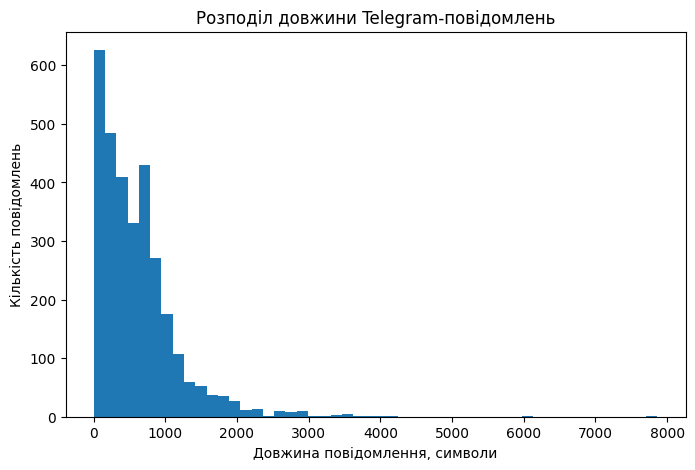

In [41]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["message_length"], bins=50)
plt.xlabel("Довжина повідомлення, символи")
plt.ylabel("Кількість повідомлень")
plt.title("Розподіл довжини Telegram-повідомлень")
plt.show()

**Розподіл повідомлень за годинами**

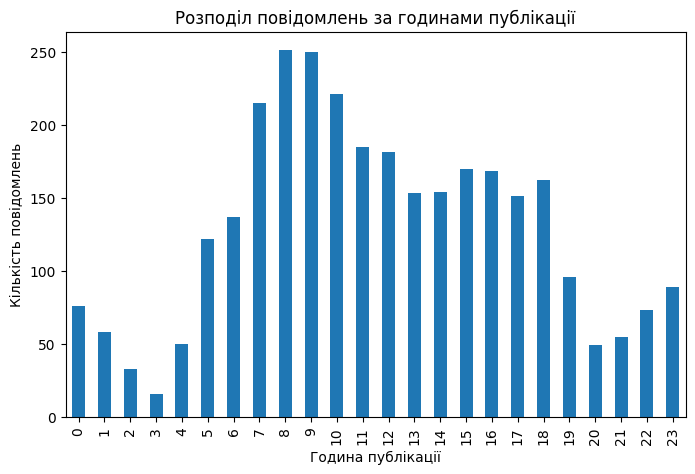

In [42]:
plt.figure(figsize=(8, 5))
df_clean["hour"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Година публікації")
plt.ylabel("Кількість повідомлень")
plt.title("Розподіл повідомлень за годинами публікації")
plt.show()

**Видалення службової колонки перед збереженням**

In [43]:
df_clean = df_clean.drop(columns=["text_for_duplicate_check"])

**Збереження очищеного датасету**

In [44]:
df_clean.to_csv(
    CLEAN_MESSAGES_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Очищений датасет збережено:")
print(CLEAN_MESSAGES_PATH)

print("Фінальний розмір очищеного датасету:", df_clean.shape)

Очищений датасет збережено:
/content/drive/MyDrive/telegram_spam_diploma/data/processed/telegram_messages_clean.csv
Фінальний розмір очищеного датасету: (3115, 15)


##Підготовка датасету до ручної розмітки
**Завантаження очищеного датасету**

In [157]:
df_clean = pd.read_csv(CLEAN_MESSAGES_PATH)

print("Розмір очищеного датасету:", df_clean.shape)
df_clean.head()

Розмір очищеного датасету: (3115, 15)


,message_id,source,source_category,text,date,views,forwards,has_media,message_length,date_only,hour,day_of_week,month,manual_label,label_status
0,89867,kievinfo_kyiv,news,"🛴❌Планують конфіскувати електросамокати в українців за порушення ПДР, а людей — відправляти на виправні роботи, — законопроєкт 🔵За перше порушення — штраф у розмірі 1700 грн. 🔵За повторне порушенн...",2026-06-02 11:43:29+00:00,103288,927,0,479,2026-06-02,11,1,6,NaN,unlabeled
1,89866,kievinfo_kyiv,news,"**У Києві скандал. Причина — **[**намети 🏕️ , які люди розставляють у метро**](https://t.me/kievinfo_kyiv/89677)** під час масованих атак** Кияни, які прийшли в метро пізніше, скаржаться, що **нам...",2026-06-02 10:54:51+00:00,182276,1544,1,496,2026-06-02,10,1,6,NaN,unlabeled
2,89857,kievinfo_kyiv,news,Ось такий стовп ДИМУ 💥 Видно після падіння БПЛА 🚀 [ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot 🇺🇦 ➡️ [**ПІДПИСАТИСЬ**](https://t.me/+aAaZ8kQkkpo2Zj...,2026-06-02 10:30:12+00:00,209481,921,1,249,2026-06-02,10,1,6,NaN,unlabeled
3,89856,kievinfo_kyiv,news,**✅ВІДБІЙ ПОВІТРЯНОЇ ТРИВОГИ ✅**,2026-06-02 10:27:53+00:00,195385,34,0,32,2026-06-02,10,1,6,NaN,unlabeled
4,89855,kievinfo_kyiv,news,Видно дим в центрі міста. Наразі не відомо чи це приліт чи просто впав збитий 🚀 Очікуємо відбої✈️ [ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot 🇺🇦 ➡...,2026-06-02 10:22:59+00:00,220570,649,0,297,2026-06-02,10,1,6,NaN,unlabeled


**Функції для базових спам-ознак**

In [158]:
URL_PATTERN = r"http\S+|www\S+|t\.me/\S+"

SPAM_TRIGGER_WORDS = [
    "заробіток", "заробляй", "заробити", "дохід", "прибуток",
    "інвестуй", "інвестиції", "гроші", "бонус", "промокод", "акція",
    "виграв", "виграш", "казино", "ставки", "бет", "bet",
    "crypto", "крипта", "криптовалюта", "терміново",
    "тільки сьогодні", "безкоштовно", "перейди", "натисни",
    "підписуйся", "розіграш", "vip", "гарантовано",
    "знижка", "забирай", "отримай", "подарунок",
    "халява", "роздача", "приз", "вигода", "легкий дохід",
    "швидкий заробіток", "без вкладень", "без ризику",
    "пасивний дохід", "додатковий дохід", "фінансова свобода",
    "обмежена пропозиція", "останній шанс", "лише сьогодні",
    "гарантований прибуток", "швидкі гроші", "робота онлайн",
    "підробіток", "віддалена робота", "легкі гроші",
    "переможець", "виплата", "отримати кошти", "отримати гроші",
    "поповнення рахунку", "безкоштовний доступ", "закритий канал",
    "vip канал", "секретний канал", "ексклюзив", "забери бонус"
]

CTA_WORDS = [
    "перейди", "натисни", "підписуйся", "реєструйся",
    "напиши", "пиши", "забирай", "отримай", "долучайся",
    "тисни", "відкрий", "заходь",
    "переходь", "приєднуйся", "залиш заявку", "заповни форму",
    "напишіть", "пишіть", "переходьте", "натискайте",
    "підпишись", "зареєструйся", "забронюй", "замовляй",
    "оформлюй", "скористайся", "не пропусти", "встигни",
    "забери", "отримай зараз", "дізнайся більше", "тисни сюди",
    "пиши в особисті", "пиши в приват", "переходь за посиланням"
]

FINANCE_WORDS = [
    "дохід", "прибуток", "заробіток", "інвестиції",
    "крипта", "crypto", "usdt", "btc", "eth",
    "гроші", "грн", "долар", "доларів", "заробляй",
    "заробити", "заробляти", "виплата", "виплати",
    "переказ", "оплата", "платіж", "депозит", "баланс",
    "рахунок", "поповнення", "кешбек", "кредит", "позика",
    "інвестування", "трейдинг", "біржа", "курс валют",
    "фінанси", "фінансовий", "прибутковість", "відсотки",
    "відсоток", "ставка", "капітал", "пасивний дохід",
    "фінансова незалежність", "швидкі гроші"
]


def count_urls(text):
    text = str(text)
    return len(re.findall(URL_PATTERN, text, flags=re.IGNORECASE))


def count_trigger_words(text, words):
    text = str(text).lower()
    return sum(1 for word in words if word in text)


def count_exclamation_marks(text):
    return str(text).count("!")


def caps_ratio(text):
    text = str(text)
    letters = [ch for ch in text if ch.isalpha()]

    if len(letters) == 0:
        return 0

    upper_letters = [ch for ch in letters if ch.isupper()]
    return len(upper_letters) / len(letters)


def count_emojis_simple(text):
    text = str(text)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "]+",
        flags=re.UNICODE
    )
    return len(emoji_pattern.findall(text))

**Формуємо попередні ознаки**

In [159]:
df_labeling = df_clean.copy()

df_labeling["url_count"] = df_labeling["text"].apply(count_urls)
df_labeling["trigger_word_count"] = df_labeling["text"].apply(
    lambda x: count_trigger_words(x, SPAM_TRIGGER_WORDS)
)
df_labeling["cta_word_count"] = df_labeling["text"].apply(
    lambda x: count_trigger_words(x, CTA_WORDS)
)
df_labeling["finance_word_count"] = df_labeling["text"].apply(
    lambda x: count_trigger_words(x, FINANCE_WORDS)
)
df_labeling["exclamation_count"] = df_labeling["text"].apply(count_exclamation_marks)
df_labeling["caps_ratio"] = df_labeling["text"].apply(caps_ratio)
df_labeling["emoji_count"] = df_labeling["text"].apply(count_emojis_simple)

df_labeling[[
    "text",
    "url_count",
    "trigger_word_count",
    "cta_word_count",
    "finance_word_count",
    "exclamation_count",
    "caps_ratio",
    "emoji_count"
]].head()

,text,url_count,trigger_word_count,cta_word_count,finance_word_count,exclamation_count,caps_ratio,emoji_count
0,"🛴❌Планують конфіскувати електросамокати в українців за порушення ПДР, а людей — відправляти на виправні роботи, — законопроєкт 🔵За перше порушення — штраф у розмірі 1700 грн. 🔵За повторне порушенн...",2,0,0,1,0,0.053521,7
1,"**У Києві скандал. Причина — **[**намети 🏕️ , які люди розставляють у метро**](https://t.me/kievinfo_kyiv/89677)** під час масованих атак** Кияни, які прийшли в метро пізніше, скаржаться, що **нам...",3,0,0,0,0,0.059490,4
2,Ось такий стовп ДИМУ 💥 Видно після падіння БПЛА 🚀 [ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot 🇺🇦 ➡️ [**ПІДПИСАТИСЬ**](https://t.me/+aAaZ8kQkkpo2Zj...,3,0,0,0,0,0.256250,5
3,**✅ВІДБІЙ ПОВІТРЯНОЇ ТРИВОГИ ✅**,0,0,0,0,0,1.000000,2
4,Видно дим в центрі міста. Наразі не відомо чи це приліт чи просто впав збитий 🚀 Очікуємо відбої✈️ [ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний бот **➡️@novosty_kiev_bot 🇺🇦 ➡...,3,0,0,0,0,0.171717,5


**Попередній rule-based score для відбору на розмітку**

In [160]:
def calculate_preliminary_spam_score(row):
    score = 0

    if row["url_count"] > 0:
        score += 2

    if row["trigger_word_count"] > 0:
        score += row["trigger_word_count"] * 2

    if row["cta_word_count"] > 0:
        score += row["cta_word_count"]

    if row["finance_word_count"] > 0:
        score += row["finance_word_count"] * 2

    if row["exclamation_count"] >= 3:
        score += 1

    if row["caps_ratio"] > 0.5 and row["message_length"] > 15:
        score += 2

    if row["emoji_count"] >= 3:
        score += 1

    if row["has_media"] == 1 and row["url_count"] > 0:
        score += 1

    return score

In [161]:
df_labeling["preliminary_spam_score"] = df_labeling.apply(
    calculate_preliminary_spam_score,
    axis=1
)

df_labeling[[
    "source",
    "source_category",
    "text",
    "preliminary_spam_score"
]].sort_values("preliminary_spam_score", ascending=False).head(20)

,source,source_category,text,preliminary_spam_score
2217,Easy_Moneyyyyyyyyyyy,crypto_finance,🤑**Отримуємо 50$ від **[**TradingLeagues**](https://www.tradingleagues.app/referral?referral_code=00051881)** **🔥 💡[Trading Leagues](https://www.tradingleagues.app/referral?referral_code=00051881)...,26
2281,Easy_Moneyyyyyyyyyyy,crypto_finance,🌟**Нова роздача 7.5$ + 5$ за друга від біржі **[**BIB Exchange**](https://www.bibvip.net/register?inviteCode=1oMFpB)💰 📌__Сінгапурська біржа__[ Bib Exchange](https://www.bibvip.net/register?inviteC...,26
2314,Easy_Moneyyyyyyyyyyy,crypto_finance,**🔥Топова роздача від 50 до 150 Гривень за друга від izibank🏦** 🤔**Що потрібно зробити?** 🔹**Реєструємося** за цим [**посиланням**](https://izibank.com.ua/r/rnwX) 👈 🔹Проходимо **верифікацію** чере...,24
2395,Easy_Moneyyyyyyyyyyy,crypto_finance,🔥​​Роздача 20$ від біржі Tidex 💳 ВАЖЛИВО❗ Для нарахування нагороди – переходити за посиланням👇 https://tidex.com/referral/f6f11dc9-4c88-491b-8ceb-e467834f386c 🥸 Що потрібно зробити? 1️⃣ Пройти реє...,23
2330,Easy_Moneyyyyyyyyyyy,crypto_finance,"💎 **А**ктуальні теми на яких можна заробити💸 В каналі багато новачків, тому я зібрав список з тем, які на даний момент ще **актуальні👇**: 🔹[Отримуємо 50 Грн за реєстрацію + 50 грн за друга від Set...",22
2188,Easy_Moneyyyyyyyyyyy,crypto_finance,📌 **ОНОВЛЕНИЙ ТОП АКТУАЛЬНИХ СХЕМ БЕЗ ВКЛАДЕНЬ НА ДАНИЙ МОМЕНТ ****🤑** 🔥__Особливо рекомендую виконати схеми з відміткою __**VIP** 😀 1️⃣ 😀 **Отримуємо 150 грн за реєстрацію та 150 грн за запрошенн...,22
2195,Easy_Moneyyyyyyyyyyy,crypto_finance,📌 **ОНОВЛЕНИЙ ТОП АКТУАЛЬНИХ СХЕМ БЕЗ ВКЛАДЕНЬ НА ДАНИЙ МОМЕНТ ****🤑** 🔥__Особливо рекомендую виконати схеми з відміткою __**VIP** 😀 1️⃣ 😀 **Отримуємо 150 грн за реєстрацію та 150 грн за запрошенн...,22
2288,Easy_Moneyyyyyyyyyyy,crypto_finance,🎁 **Забираємо найлегші** **50 гривень за кожного запрошеного друга від** [**Portmone**](https://promo.portmone.com.ua/trial?ref=6015216&hash=NjAxNTIxNg==)** ****🟣** 📌Український сервіс оплати в ін...,21
1914,incrypted_UA,crypto_finance,"**Як FTX втратив портфель на $114 млрд** Після краху FTX ліквідатори продали 5% компанії Cursor за ту саму суму, яку раніше вклали, — 200 000 доларів. Під час банкрутства біржі юристи реалізували ...",21
2246,Easy_Moneyyyyyyyyyyy,crypto_finance,"📌 **ОНОВЛЕНИЙ ТОП АКТУАЛЬНИХ СХЕМ НА ДАНИЙ МОМЕНТ** 🤑 ❤️__Відправляйте у збережене, та діліться з друзями, щоб нічого не пропустити__😉 🤝__Особливо рекомендую виконати схеми з відміткою __**VIP** 😀...",21


**Дивимося розподіл score**

In [162]:
df_labeling["preliminary_spam_score"].describe()

,preliminary_spam_score
count,3115.000000
mean,4.478331
std,3.857917
min,0.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,26.000000


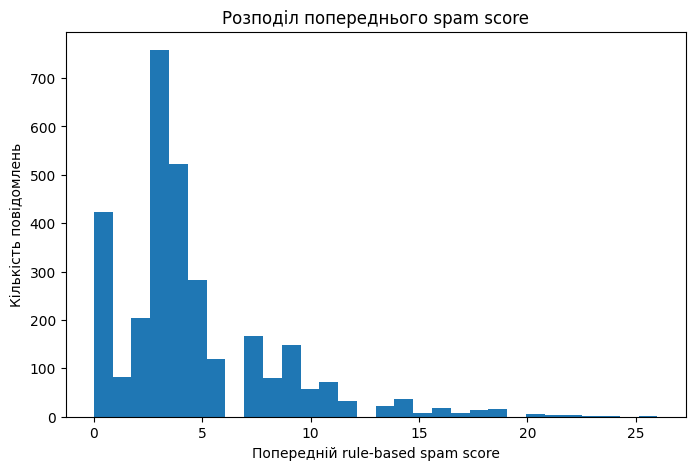

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df_labeling["preliminary_spam_score"], bins=30)
plt.xlabel("Попередній rule-based spam score")
plt.ylabel("Кількість повідомлень")
plt.title("Розподіл попереднього spam score")
plt.show()

**Перегляд прикладів за рівнем підозрілості**

In [ ]:
pd.set_option("display.max_colwidth", 250)

def show_examples_by_score(df, condition, title, n=10):

    subset = df[condition].copy()

    print("=" * 100)
    print(title)
    print("Кількість повідомлень у групі:", len(subset))
    print("=" * 100)

    if len(subset) == 0:
        print("Повідомлень у цій групі немає.")
        return

    display(
        subset[[
            "source",
            "source_category",
            "text",
            "url_count",
            "trigger_word_count",
            "cta_word_count",
            "finance_word_count",
            "exclamation_count",
            "caps_ratio",
            "emoji_count",
            "preliminary_spam_score"
        ]]
        .sort_values("preliminary_spam_score", ascending=False)
        .head(n)
    )

**Ймовірний спам**

In [ ]:
show_examples_by_score(
    df_labeling,
    df_labeling["preliminary_spam_score"] >= 5,
    "ЙМОВІРНИЙ СПАМ: повідомлення з високим preliminary_spam_score",
    n=10
)

ЙМОВІРНИЙ СПАМ: повідомлення з високим preliminary_spam_score
Кількість повідомлень у групі: 1111


,source,source_category,text,url_count,trigger_word_count,cta_word_count,finance_word_count,exclamation_count,caps_ratio,emoji_count,preliminary_spam_score
2252,Easy_Moneyyyyyyyyyyy,crypto_finance,🌟**Нова роздача 7.5$ + 5$ за друга від біржі **[**BIB Exchange**](https://www.bibvip.net/register?inviteCode=1oMFpB)💰 📌__Сінгапурська біржа__[ Bib Exchange](https://www.bibvip.net/register?inviteCode=1oMFpB)__ запустила промо для нових користувач...,6,5,0,6,0,0.059441,14,26
2188,Easy_Moneyyyyyyyyyyy,crypto_finance,"🤑**Отримуємо 50$ від **[**TradingLeagues**](https://www.tradingleagues.app/referral?referral_code=00051881)** **🔥 💡[Trading Leagues](https://www.tradingleagues.app/referral?referral_code=00051881) - це щось на кшталт казино/фентезі біржі, де можн...",5,5,0,6,0,0.034314,16,26
2285,Easy_Moneyyyyyyyyyyy,crypto_finance,**🔥Топова роздача від 50 до 150 Гривень за друга від izibank🏦** 🤔**Що потрібно зробити?** 🔹**Реєструємося** за цим [**посиланням**](https://izibank.com.ua/r/rnwX) 👈 🔹Проходимо **верифікацію** через **Дію** (можна через **id** або **закордонний па...,3,5,0,5,0,0.043668,13,24
2366,Easy_Moneyyyyyyyyyyy,crypto_finance,🔥​​Роздача 20$ від біржі Tidex 💳 ВАЖЛИВО❗ Для нарахування нагороди – переходити за посиланням👇 https://tidex.com/referral/f6f11dc9-4c88-491b-8ceb-e467834f386c 🥸 Що потрібно зробити? 1️⃣ Пройти реєстрацію 👆(посилання вище) 2️⃣ Пройти верифікацію о...,1,4,0,5,3,0.120253,16,23
751,truexanewsua,news,**📣** С**ТАВАЙ **[**МІЛЬЙОНЕРОМ СІТІ**](https://bit.ly/SlotCityua_TruexaNewsua)** — ЗАБИРАЙ СВІЙ 1 000 000💰 ** У Сіті оголошено «полювання» на мільйони! П’ять тижнів поспіль ми роздаємо по **1 000 000💰** **Як отримати свій мільйон?** 🎟 **Депозит:...,2,7,2,1,3,0.172680,7,23
2301,Easy_Moneyyyyyyyyyyy,crypto_finance,"💎 **А**ктуальні теми на яких можна заробити💸 В каналі багато новачків, тому я зібрав список з тем, які на даний момент ще **актуальні👇**: 🔹[Отримуємо 50 Грн за реєстрацію + 50 грн за друга від SettlePay](https://t.me/Easy_Moneyyyyyyyyyyy/241)** *...",6,5,0,4,0,0.067485,10,22
2166,Easy_Moneyyyyyyyyyyy,crypto_finance,📌 **ОНОВЛЕНИЙ ТОП АКТУАЛЬНИХ СХЕМ БЕЗ ВКЛАДЕНЬ НА ДАНИЙ МОМЕНТ ****🤑** 🔥__Особливо рекомендую виконати схеми з відміткою __**VIP** 😀 1️⃣ 😀 **Отримуємо 150 грн за реєстрацію та 150 грн за запрошення друга БЕЗ ВКЛАДЕНЬ від Укрсіббанк** 🏦 **https://...,12,5,0,4,0,0.211424,26,22
2159,Easy_Moneyyyyyyyyyyy,crypto_finance,📌 **ОНОВЛЕНИЙ ТОП АКТУАЛЬНИХ СХЕМ БЕЗ ВКЛАДЕНЬ НА ДАНИЙ МОМЕНТ ****🤑** 🔥__Особливо рекомендую виконати схеми з відміткою __**VIP** 😀 1️⃣ 😀 **Отримуємо 150 грн за реєстрацію та 150 грн за запрошення друга БЕЗ ВКЛАДЕНЬ від Укрсіббанк** 🏦 **https://...,13,5,0,4,0,0.208472,26,22
2217,Easy_Moneyyyyyyyyyyy,crypto_finance,"📌 **ОНОВЛЕНИЙ ТОП АКТУАЛЬНИХ СХЕМ НА ДАНИЙ МОМЕНТ** 🤑 ❤️__Відправляйте у збережене, та діліться з друзями, щоб нічого не пропустити__😉 🤝__Особливо рекомендую виконати схеми з відміткою __**VIP** 😀 1️⃣ **200 грн тобі та 200 грн за запрошення друга...",11,6,1,2,1,0.233410,25,21
1761,incrypted_UA,crypto_finance,"**Як FTX втратив портфель на $114 млрд** Після краху FTX ліквідатори продали 5% компанії Cursor за ту саму суму, яку раніше вклали, — 200 000 доларів. Під час банкрутства біржі юристи реалізували цей пакет, але якби проєкт Сема Бенкмана-Фріда не ...",4,3,0,6,0,0.045991,0,21


**Сіра зона**

In [ ]:
show_examples_by_score(
    df_labeling,
    (df_labeling["preliminary_spam_score"] >= 3) &
    (df_labeling["preliminary_spam_score"] <= 4),
    "СІРА ЗОНА: повідомлення із середнім preliminary_spam_score",
    n=10
)

СІРА ЗОНА: повідомлення із середнім preliminary_spam_score
Кількість повідомлень у групі: 1324


,source,source_category,text,url_count,trigger_word_count,cta_word_count,finance_word_count,exclamation_count,caps_ratio,emoji_count,preliminary_spam_score
2749,ksd_bookclub,books_content,"Сьогодні, 13 березня, у Бізнес-школі МІМ у Києві відбудеться церемонія нагородження **KBU Awards 2025** — національної премії у сфері українського нонфікшну📚 Із понад 300 поданих книг до фіналу увійшли 28 видань, а переможців визначать у п’яти но...",2,0,0,0,0,0.034294,3,4
2748,ksd_bookclub,books_content,"**Виробничі романи – що це таке?🤔📚** ✒️ **Артур Гейлі** – автор, який пише художні романи, але занурюється у функціонування цілих структур. Він став відомим завдяки своєму особливому підходу до роботи. Перед написанням кожного роману він місяцями...",2,0,0,0,1,0.026316,6,4
2741,ksd_bookclub,books_content,"**Щоб стати безсмертною, спочатку потрібно вижити…** 🔥 Спарта вже не та: її слава згасла, боги втрачають силу, а люди винайшли спосіб вбивати навіть безсмертних. У військовій академії Алексіс має вибороти право на власне безсмертя — та поки чудов...",2,0,0,0,1,0.022260,9,4
2739,ksd_bookclub,books_content,"Обговорення книги [«Тишени»](https://ksd.ua/product/tysheny) з Мариною Бородіною, які чекають на вас вже цього тижня!😉💫 Якщо ви з Дніпра та Одеси, обовʼязково завітайте цими вихідними на наші презентації📚: 📆 **21 березня о 14:00 📍м. Дніпро, вул. ...",1,0,0,0,2,0.042042,7,4
2738,ksd_bookclub,books_content,"**Схоже, що нас чекає екранізація серії **[**«Місто вітрів»**](https://ksd.ua/series/misto-vitriv)**🔥 ** Поки що це тільки чутки, авторка не підтверджувала інформації, але новина зʼявилася у [статті Deadline.](https://deadline.com/2026/03/premedi...",2,0,0,0,0,0.020173,3,4
2737,ksd_bookclub,books_content,"**ЕКСЛЮЗИВНО для українських читачів інтервʼю з Робін Гобб😍🔥 ** «Я дуже рада відповісти на запитання перед тим, як КСД опублікує книгу «Місія Блазня». Дякую за можливість звернутися до українських читачів!» – З повагою, Robin Hobb У квітні (за ум...",2,0,0,0,1,0.053211,5,4
2736,ksd_bookclub,books_content,"«Якщо вам здається, що людина плаче через якусь дурницю, це не означає, що проблеми немає. Просто ця людина відрізняється від вас» Заможна родина, зловісний будинок, ідеальний чоловік, молода дружина з маленькою дитиною, і святкування 16-річчя до...",2,0,0,0,2,0.027540,9,4
2734,ksd_bookclub,books_content,"У мережі з’явилися перші постери **«Дюна: частина третя»** Дені Вільньова. Ця історія стане ще темнішою й напруженішою🖤 Ось Тімоті Шаламе в ролі Пола Атріда, Роберт Патінсон — новий лиходій😱 та інші. Прем’єра запланована на грудень 2026 року. Ви ...",1,0,0,0,0,0.067227,4,4
2733,ksd_bookclub,books_content,"Вчора ввечері дочитала новий трилер від КСД, а саме [«Відлік до смерті»](https://ksd.ua/product/vidlik-do-smerti-knyha-1) Андреаса Ґрубера. Мені подобається цей жанр і те, скільки цікавих деталей можна додати у вже звичний сюжет. З одного боку, в...",2,0,0,0,0,0.027891,4,4
2732,ksd_bookclub,books_content,"Невже це саме те, про що ми всі думаємо? 🥹 Пиши, Ребекко, пиши 🙏🏻💫 А нам час знайомитися (або перечитувати) твоє фентезі: https://ksd.ua/series/empireji",1,0,1,0,0,0.035398,2,4


**Ймовірний не спам**

In [ ]:
show_examples_by_score(
    df_labeling,
    df_labeling["preliminary_spam_score"] <= 2,
    "ЙМОВІРНИЙ НЕ СПАМ: повідомлення з низьким preliminary_spam_score",
    n=10
)

ЙМОВІРНИЙ НЕ СПАМ: повідомлення з низьким preliminary_spam_score
Кількість повідомлень у групі: 631


,source,source_category,text,url_count,trigger_word_count,cta_word_count,finance_word_count,exclamation_count,caps_ratio,emoji_count,preliminary_spam_score
123,kievinfo_kyiv,news,❗️**Відбувся обмін військовополоненими 205 на 205 ** 🇺🇦 [**Київ ІНФО**](https://t.me/+aAaZ8kQkkpo2ZjRi) | [Надіслати новину](https://t.me/novosty_kiev_bot),2,0,0,0,0,0.118812,2,2
94,kievinfo_kyiv,news,"🔴**Білорусь нападе на Україну: зараз є тільки два питання - вектор руху і коли. Путін хоче, щоб Лукашенко воював проти України, - Кулеба **🇺🇦 [**Київ ІНФО**](https://t.me/+aAaZ8kQkkpo2ZjRi) | [Надіслати новину](https://t.me/novosty_kiev_bot)",2,0,0,0,0,0.098837,2,2
80,kievinfo_kyiv,news,"🔴Зеленський: цілком **справедливі наші відповіді на російське затягування війни та удари по наших містах і громадах**. Цього разу українські далекобійні санкції досягли Московського регіону, і **ми чітко говоримо росіянам: їхня держава повинна за...",2,0,0,0,1,0.061508,2,2
76,kievinfo_kyiv,news,"🔴КОВА: у Броварському районі внаслідок атаки пошкоджено будівлю АТП та два приватні будинки. На щастя, постраждалих серед населення немає. 🇺🇦 [**Київ ІНФО**](https://t.me/+aAaZ8kQkkpo2ZjRi) | [Надіслати новину](https://t.me/novosty_kiev_bot)",2,0,0,0,0,0.109890,2,2
167,kievinfo_kyiv,news,"❗️**На лівому березі столиці внаслідок атаки вороги перебої з водопостачанням**, – Кличко 🇺🇦 [**Київ ІНФО**](https://t.me/+aAaZ8kQkkpo2ZjRi) | [Надіслати новину](https://t.me/novosty_kiev_bot)",2,0,0,0,0,0.094891,2,2
161,kievinfo_kyiv,news,**✅ВІДБІЙ ПОВІТРЯНОЇ у м. Києві**,0,0,0,0,0,0.739130,1,2
52,kievinfo_kyiv,news,"‼️**Путін хоче контроль над Києвом** **та** **Одесою**: він планує висунути нові територіальні вимоги **у разі захоплення Донбасу**, — «FT». 🇺🇦 [**Київ ІНФО**](https://t.me/+aAaZ8kQkkpo2ZjRi) | [Надіслати новину](https://t.me/novosty_kiev_bot)",2,0,0,0,0,0.103030,1,2
2779,ksd_bookclub,books_content,Пропонуємо невеликий вечірній інтерактив на ваше знання березневих новинок😌❤️ Спробуйте вгадати з якої книжечки ця провокативна присвята?😏🔥 Пишіть ваші здогадки у коментарях!🙌🏻,0,0,1,0,1,0.020548,3,2
2706,ksd_bookclub,books_content,Остання година потроєння КСДкоїнів. Ви точно все придбали?😏💫 [➡️ ](https://ksd.ua/)[https://ksd.ua](https://ksd.ua/),1,0,0,0,0,0.063291,2,2
2705,ksd_bookclub,books_content,⏳ Останні 15 хвилин! Ви точно нічого не забули?🤭 [https://ksd.ua](https://ksd.ua/),1,0,0,0,1,0.037037,1,2


**Формуємо вибірку для ручної розмітки**

In [ ]:
HIGH_SCORE_THRESHOLD = 5
MID_SCORE_MIN = 2
MID_SCORE_MAX = 4

N_HIGH = 500
N_MID = 500
N_LOW = 200
TARGET_TOTAL = 1200

high_score_pool = df_labeling[
    df_labeling["preliminary_spam_score"] >= HIGH_SCORE_THRESHOLD
]

mid_score_pool = df_labeling[
    (df_labeling["preliminary_spam_score"] >= MID_SCORE_MIN) &
    (df_labeling["preliminary_spam_score"] <= MID_SCORE_MAX)
]

low_score_pool = df_labeling[
    df_labeling["preliminary_spam_score"] < MID_SCORE_MIN
]

high_score_sample = high_score_pool.sample(
    n=min(N_HIGH, len(high_score_pool)),
    random_state=SEED
).copy()

mid_score_sample = mid_score_pool.sample(
    n=min(N_MID, len(mid_score_pool)),
    random_state=SEED
).copy()

low_score_sample = low_score_pool.sample(
    n=min(N_LOW, len(low_score_pool)),
    random_state=SEED
).copy()

high_score_sample["labeling_group"] = "probable_spam"
mid_score_sample["labeling_group"] = "gray_zone"
low_score_sample["labeling_group"] = "probable_not_spam"

df_for_labeling = pd.concat([
    high_score_sample,
    mid_score_sample,
    low_score_sample
]).drop_duplicates(subset=["text"]).reset_index(drop=True)

remaining_n = TARGET_TOTAL - len(df_for_labeling)

if remaining_n > 0:
    already_selected_texts = set(df_for_labeling["text"])

    remaining_pool = df_labeling[
        ~df_labeling["text"].isin(already_selected_texts)
    ].copy()

    additional_sample = remaining_pool.sample(
        n=min(remaining_n, len(remaining_pool)),
        random_state=SEED
    ).copy()

    additional_sample["labeling_group"] = "additional_random"

    df_for_labeling = pd.concat([
        df_for_labeling,
        additional_sample
    ]).drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Кількість повідомлень для ручної розмітки:", len(df_for_labeling))

print("\nРозподіл за preliminary_spam_score:")
print(df_for_labeling["preliminary_spam_score"].describe())

print("\nКількість за групами:")
print(df_for_labeling["labeling_group"].value_counts())

print("\nРозмір пулів у всьому датасеті:")
print("High score pool:", len(high_score_pool))
print("Mid score pool:", len(mid_score_pool))
print("Low score pool:", len(low_score_pool))

Кількість повідомлень для ручної розмітки: 1200

Розподіл за preliminary_spam_score:
count    1200.000000
mean        4.833333
std         3.900201
min         0.000000
25%         3.000000
50%         4.000000
75%         7.000000
max        26.000000
Name: preliminary_spam_score, dtype: float64

Кількість за групами:
labeling_group
gray_zone            498
probable_spam        494
probable_not_spam    199
additional_random      9
Name: count, dtype: int64

Розмір пулів у всьому датасеті:
High score pool: 1111
Mid score pool: 1487
Low score pool: 468


**Додаємо колонки для ручної розмітки**

In [ ]:
df_for_labeling["manual_label"] = ""
df_for_labeling["label_comment"] = ""

**Вибираємо зручні колонки для розмітки**

In [ ]:
labeling_columns = [
    "manual_label",
    "label_comment",
    "labeling_group",
    "text",
    "source",
    "source_category",
    "date",
    "message_length",
    "url_count",
    "trigger_word_count",
    "cta_word_count",
    "finance_word_count",
    "exclamation_count",
    "caps_ratio",
    "emoji_count",
    "preliminary_spam_score",
    "views",
    "forwards",
    "has_media"
]

df_for_labeling = df_for_labeling[labeling_columns]

df_for_labeling.head()

,manual_label,label_comment,labeling_group,text,source,source_category,date,message_length,url_count,trigger_word_count,cta_word_count,finance_word_count,exclamation_count,caps_ratio,emoji_count,preliminary_spam_score,views,forwards,has_media
0,,,probable_spam,"**Біткоїн повторює сценарій 2022 року?** Аналітик Ali Charts [вважає](https://x.com/alicharts/status/2050078007511953497), що поточна структура BTC нагадує формування дна 2022 року. Якщо аналогія збережеться, ринок може побачити ще один імпульс д...",incrypted_UA,crypto_finance,2026-05-01 08:01:14+00:00,417,4,0,0,1,0,0.054422,0,5,791,7,1
1,,,probable_spam,**GM!** - BTC ≈$74 700 (-0.26%) - ETH ≈$2 330 (-1.23%) - SOL ≈$89 (+3.17%) - Капіталізація ринку ≈$2.5T (+0.18%) - Індекс страху і жадібності: 55 (Нейтральний) - Індекс альтсезону: 43 Детальніше в інфографіці. Головні анонси наших івентів та інши...,incrypted_UA,crypto_finance,2026-04-17 05:01:02+00:00,414,3,0,0,3,1,0.112450,0,9,728,1,1
2,,,probable_spam,"**27 травня Київ стає столицею спортивного маркетингу 🏆** SBC Summit Ukraine повертається вп'яте – і цього разу масштаб справді інший. КВЦ «Парковий», 1200+ учасників, 60+ спікерів, шість тематичних блоків і найширша програма за всю історію конфе...",truexanewsua,news,2026-05-19 11:40:15+00:00,1550,6,2,0,0,2,0.073756,6,8,605593,37,1
3,,,probable_spam,**Розпочався другий тиждень кампанії від Aster та WLFI** Раніше ми писали про кампанію у [дописі](https://t.me/incrypted_airdrops/3979). За перший тиждень було розподілено 625 тис. токенів WLFI без урахування винагород за утримання USD1А на платф...,incrypted_UA,crypto_finance,2026-03-26 16:12:01+00:00,1018,7,1,0,3,0,0.054194,1,11,723,0,1
4,,,probable_spam,**Прототип сайту за кілька кліків: що таке Google Stitch і як він змінює дизайн ** https://incrypted.com/ua/google-stitch-ai-ui-design-guide/ Після оновлення інструменту Stitch від Google Labs акції Figma впали майже на 9% — ринок серйозно відреа...,incrypted_UA,crypto_finance,2026-03-23 18:01:52+00:00,709,5,1,0,0,0,0.040000,0,5,869,19,1


**Збереження файлу для ручної розмітки**

In [ ]:
print("Розмір вибірки для ручної розмітки:", df_for_labeling.shape)

print("\nКількість повідомлень за групами:")
print(df_for_labeling["labeling_group"].value_counts())

print("\nРозподіл preliminary_spam_score:")
print(df_for_labeling["preliminary_spam_score"].describe())

print("\nПеревірка manual_label:")
print(df_for_labeling["manual_label"].value_counts(dropna=False))

Розмір вибірки для ручної розмітки: (1200, 19)

Кількість повідомлень за групами:
labeling_group
gray_zone            498
probable_spam        494
probable_not_spam    199
additional_random      9
Name: count, dtype: int64

Розподіл preliminary_spam_score:
count    1200.000000
mean        4.833333
std         3.900201
min         0.000000
25%         3.000000
50%         4.000000
75%         7.000000
max        26.000000
Name: preliminary_spam_score, dtype: float64

Перевірка manual_label:
manual_label
    1200
Name: count, dtype: int64


In [ ]:
LABELING_FILE_PATH = os.path.join(PROCESSED_DIR, "telegram_messages_for_labeling.csv")

df_for_labeling.to_csv(
    LABELING_FILE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Файл для ручної розмітки оновлено:")
print(LABELING_FILE_PATH)
print("Кількість повідомлень для розмітки:", len(df_for_labeling))

Файл для ручної розмітки оновлено:
/content/drive/MyDrive/telegram_spam_diploma/data/processed/telegram_messages_for_labeling.csv
Кількість повідомлень для розмітки: 1200


##Підготовка розміченого датасету до навчання моделей

**Завантаження розміченого файлу**

In [45]:
LABELED_INPUT_PATH = os.path.join(
    PROCESSED_DIR,
    "telegram_messages_for_labeling.csv"
)

df_labeled = pd.read_csv(LABELED_INPUT_PATH)

print("Розмір завантаженого розміченого датасету:", df_labeled.shape)
df_labeled.head()

Розмір завантаженого розміченого датасету: (1200, 19)


,manual_label,label_comment,labeling_group,text,source,source_category,date,message_length,url_count,trigger_word_count,cta_word_count,finance_word_count,exclamation_count,caps_ratio,emoji_count,preliminary_spam_score,views,forwards,has_media
0,1,NaN,probable_spam,"😱**Ви вже бачили, що твориться сьогодні на ринку?**🤯 **CZ** (засновник Binance) просто геній 🤓 📉Просадив своїми твітами біржу **FTX** та її токен, а тепер купує ці самі токени😄 🧐На секундочку, **F...",Easy_Moneyyyyyyyyyyy,crypto_finance,2022-11-08 17:00:04+00:00,480,2,1,0,2,0,0.099698,9,10,1047,5,1
1,0,NaN,probable_spam,"**ОККО сплатила майже 7,3 млрд грн податків за перший квартал **💪 За перший квартал 2026 року група ОККО сплатила майже 7,3 млрд грн податків — це на 35,6% більше, ніж за аналогічний період торік....",truexanewsua,news,2026-05-13 16:26:51+00:00,777,4,0,0,1,0,0.066550,1,5,777221,69,1
2,0,NaN,probable_spam,**Останні години діє ПОТРОЄННЯ КСДкоїнів❤️** Ще є шанс встигнути взяти кілька книжок і отримати більше бонусів на ваші наступні покупки😉🔥: https://ksd.ua,ksd_bookclub,books_content,2026-03-23 19:05:09+00:00,153,1,1,0,0,0,0.116667,2,5,23954,51,1
3,0,NaN,probable_spam,🔼**BTC різко підскочив вище $71 000 на тлі новин щодо Ірану** Дональд Трамп [заявив](https://incrypted.com/ua/zajava-trampa-pro-iran-pidnjala-bitkojin-vyshche-71-000/) про «продуктивні переговори»...,incrypted_UA,crypto_finance,2026-03-23 11:11:45+00:00,532,4,0,0,1,0,0.043257,1,5,1019,10,1
4,0,NaN,probable_spam,"**Dragonfly інвестував $50 млн у Variational** Проєкт Variational [завершив](https://x.com/variational_io/status/2057097346086047982) раунд серії A на значну суму в $50 млн, лід-інвестором виступи...",incrypted_UA,crypto_finance,2026-05-20 15:38:10+00:00,1410,11,1,0,1,0,0.075117,1,7,505,0,1


**Перевірка колонки manual_label**

In [46]:
LABELED_INPUT_PATH = os.path.join(
    PROCESSED_DIR,
    "telegram_messages_for_labeling.csv"
)

df_labeled = pd.read_csv(LABELED_INPUT_PATH)

print("Розмір завантаженого розміченого датасету:", df_labeled.shape)
df_labeled.head()

Розмір завантаженого розміченого датасету: (1200, 19)


,manual_label,label_comment,labeling_group,text,source,source_category,date,message_length,url_count,trigger_word_count,cta_word_count,finance_word_count,exclamation_count,caps_ratio,emoji_count,preliminary_spam_score,views,forwards,has_media
0,1,NaN,probable_spam,"😱**Ви вже бачили, що твориться сьогодні на ринку?**🤯 **CZ** (засновник Binance) просто геній 🤓 📉Просадив своїми твітами біржу **FTX** та її токен, а тепер купує ці самі токени😄 🧐На секундочку, **F...",Easy_Moneyyyyyyyyyyy,crypto_finance,2022-11-08 17:00:04+00:00,480,2,1,0,2,0,0.099698,9,10,1047,5,1
1,0,NaN,probable_spam,"**ОККО сплатила майже 7,3 млрд грн податків за перший квартал **💪 За перший квартал 2026 року група ОККО сплатила майже 7,3 млрд грн податків — це на 35,6% більше, ніж за аналогічний період торік....",truexanewsua,news,2026-05-13 16:26:51+00:00,777,4,0,0,1,0,0.066550,1,5,777221,69,1
2,0,NaN,probable_spam,**Останні години діє ПОТРОЄННЯ КСДкоїнів❤️** Ще є шанс встигнути взяти кілька книжок і отримати більше бонусів на ваші наступні покупки😉🔥: https://ksd.ua,ksd_bookclub,books_content,2026-03-23 19:05:09+00:00,153,1,1,0,0,0,0.116667,2,5,23954,51,1
3,0,NaN,probable_spam,🔼**BTC різко підскочив вище $71 000 на тлі новин щодо Ірану** Дональд Трамп [заявив](https://incrypted.com/ua/zajava-trampa-pro-iran-pidnjala-bitkojin-vyshche-71-000/) про «продуктивні переговори»...,incrypted_UA,crypto_finance,2026-03-23 11:11:45+00:00,532,4,0,0,1,0,0.043257,1,5,1019,10,1
4,0,NaN,probable_spam,"**Dragonfly інвестував $50 млн у Variational** Проєкт Variational [завершив](https://x.com/variational_io/status/2057097346086047982) раунд серії A на значну суму в $50 млн, лід-інвестором виступи...",incrypted_UA,crypto_finance,2026-05-20 15:38:10+00:00,1410,11,1,0,1,0,0.075117,1,7,505,0,1


**Приведення manual_label до числового формату**

In [47]:
df_labeled["manual_label"] = pd.to_numeric(
    df_labeled["manual_label"],
    errors="coerce"
)

print("Після перетворення manual_label:")
print(df_labeled["manual_label"].value_counts(dropna=False))

Після перетворення manual_label:
manual_label
0    948
1    252
Name: count, dtype: int64


**Перевірка нерозмічених або некоректних рядків**

In [48]:
invalid_labels = df_labeled[
    ~df_labeled["manual_label"].isin([0, 1])
]

print("Кількість рядків з некоректною або порожньою міткою:", len(invalid_labels))

invalid_labels[[
    "text",
    "labeling_group",
    "preliminary_spam_score",
    "manual_label"
]].head(20)

Кількість рядків з некоректною або порожньою міткою: 0


,text,labeling_group,preliminary_spam_score,manual_label


**Залишаємо тільки коректно розмічені повідомлення**

In [49]:
df_labeled = df_labeled[df_labeled["manual_label"].isin([0, 1])].copy()
df_labeled["manual_label"] = df_labeled["manual_label"].astype(int)

print("Фінальний розмір після перевірки:", df_labeled.shape)

print("\nФінальний розподіл класів:")
print(df_labeled["manual_label"].value_counts())

Фінальний розмір після перевірки: (1200, 19)

Фінальний розподіл класів:
manual_label
0    948
1    252
Name: count, dtype: int64


**Баланс класів**

In [50]:
label_distribution = df_labeled["manual_label"].value_counts().reset_index()
label_distribution.columns = ["manual_label", "count"]

label_distribution["class_name"] = label_distribution["manual_label"].map({
    0: "not_spam",
    1: "spam"
})

label_distribution["share_percent"] = (
    label_distribution["count"] / len(df_labeled) * 100
).round(2)

label_distribution

,manual_label,count,class_name,share_percent
0,0,948,not_spam,79.0
1,1,252,spam,21.0


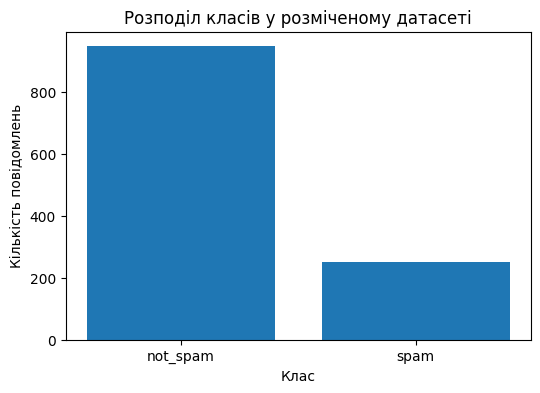

In [51]:
plt.figure(figsize=(6, 4))
plt.bar(label_distribution["class_name"], label_distribution["count"])
plt.xlabel("Клас")
plt.ylabel("Кількість повідомлень")
plt.title("Розподіл класів у розміченому датасеті")
plt.show()

**Перевірка розмітки за групами**

In [52]:
group_label_stats = pd.crosstab(
    df_labeled["labeling_group"],
    df_labeled["manual_label"],
    margins=True
)

group_label_stats

manual_label,0,1,All
labeling_group,,,
additional_random,7,4,11
gray_zone,464,31,495
probable_not_spam,195,3,198
probable_spam,282,214,496
All,948,252,1200


**Підготовка тексту для моделей**

In [53]:
def prepare_text_for_model(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text

In [54]:
df_labeled["clean_text"] = df_labeled["text"].apply(prepare_text_for_model)

df_labeled[["text", "clean_text", "manual_label"]].head()

,text,clean_text,manual_label
0,"😱**Ви вже бачили, що твориться сьогодні на ринку?**🤯 **CZ** (засновник Binance) просто геній 🤓 📉Просадив своїми твітами біржу **FTX** та її токен, а тепер купує ці самі токени😄 🧐На секундочку, **F...","😱**Ви вже бачили, що твориться сьогодні на ринку?**🤯 **CZ** (засновник Binance) просто геній 🤓 📉Просадив своїми твітами біржу **FTX** та її токен, а тепер купує ці самі токени😄 🧐На секундочку, **F...",1
1,"**ОККО сплатила майже 7,3 млрд грн податків за перший квартал **💪 За перший квартал 2026 року група ОККО сплатила майже 7,3 млрд грн податків — це на 35,6% більше, ніж за аналогічний період торік....","**ОККО сплатила майже 7,3 млрд грн податків за перший квартал **💪 За перший квартал 2026 року група ОККО сплатила майже 7,3 млрд грн податків — це на 35,6% більше, ніж за аналогічний період торік....",0
2,**Останні години діє ПОТРОЄННЯ КСДкоїнів❤️** Ще є шанс встигнути взяти кілька книжок і отримати більше бонусів на ваші наступні покупки😉🔥: https://ksd.ua,**Останні години діє ПОТРОЄННЯ КСДкоїнів❤️** Ще є шанс встигнути взяти кілька книжок і отримати більше бонусів на ваші наступні покупки😉🔥: https://ksd.ua,0
3,🔼**BTC різко підскочив вище $71 000 на тлі новин щодо Ірану** Дональд Трамп [заявив](https://incrypted.com/ua/zajava-trampa-pro-iran-pidnjala-bitkojin-vyshche-71-000/) про «продуктивні переговори»...,🔼**BTC різко підскочив вище $71 000 на тлі новин щодо Ірану** Дональд Трамп [заявив](https://incrypted.com/ua/zajava-trampa-pro-iran-pidnjala-bitkojin-vyshche-71-000/) про «продуктивні переговори»...,0
4,"**Dragonfly інвестував $50 млн у Variational** Проєкт Variational [завершив](https://x.com/variational_io/status/2057097346086047982) раунд серії A на значну суму в $50 млн, лід-інвестором виступи...","**Dragonfly інвестував $50 млн у Variational** Проєкт Variational [завершив](https://x.com/variational_io/status/2057097346086047982) раунд серії A на значну суму в $50 млн, лід-інвестором виступи...",0


**Перевірка ознак**

In [55]:
feature_columns = [
    "message_length",
    "url_count",
    "trigger_word_count",
    "cta_word_count",
    "finance_word_count",
    "exclamation_count",
    "caps_ratio",
    "emoji_count",
    "preliminary_spam_score",
    "views",
    "forwards",
    "has_media"
]

missing_features = [col for col in feature_columns if col not in df_labeled.columns]

if len(missing_features) == 0:
    print("Усі необхідні ознаки присутні.")
else:
    print("Відсутні ознаки:", missing_features)

Усі необхідні ознаки присутні.


**Збереження фінального розміченого датасету**

In [56]:
FINAL_LABELED_PATH = os.path.join(
    PROCESSED_DIR,
    "telegram_messages_labeled_final.csv"
)

df_labeled.to_csv(
    FINAL_LABELED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Фінальний розмічений датасет збережено:")
print(FINAL_LABELED_PATH)
print("Розмір:", df_labeled.shape)

Фінальний розмічений датасет збережено:
/content/drive/MyDrive/telegram_spam_diploma/data/processed/telegram_messages_labeled_final.csv
Розмір: (1200, 20)


**Резервна копія**

In [57]:
LABELED_BACKUP_PATH = os.path.join(
    PROCESSED_DIR,
    "telegram_messages_labeled_backup.csv"
)

df_labeled.to_csv(
    LABELED_BACKUP_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Резервну копію збережено:")
print(LABELED_BACKUP_PATH)

Резервну копію збережено:
/content/drive/MyDrive/telegram_spam_diploma/data/processed/telegram_messages_labeled_backup.csv


**Поділ на train/test**

In [58]:
before = len(df_labeled)

df_labeled = df_labeled.drop_duplicates(
    subset=["clean_text"]
).reset_index(drop=True)

after = len(df_labeled)

print("Видалено дублікатів перед train/test split:", before - after)
print("Розмір датасету після видалення дублікатів:", df_labeled.shape)

print("\nРозподіл класів після видалення дублікатів:")
print(df_labeled["manual_label"].value_counts())

Видалено дублікатів перед train/test split: 4
Розмір датасету після видалення дублікатів: (1196, 20)

Розподіл класів після видалення дублікатів:
manual_label
0    948
1    248
Name: count, dtype: int64


In [59]:
from sklearn.model_selection import train_test_split

X = df_labeled[["clean_text"] + feature_columns].copy()
y = df_labeled["manual_label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train size: (956, 13)
Test size: (240, 13)

Train label distribution:
manual_label
0    758
1    198
Name: count, dtype: int64

Test label distribution:
manual_label
0    190
1     50
Name: count, dtype: int64


**Збереження train/test вибірок**

In [60]:
TRAIN_DATA_PATH = os.path.join(PROCESSED_DIR, "train_data.csv")
TEST_DATA_PATH = os.path.join(PROCESSED_DIR, "test_data.csv")

train_df = X_train.copy()
train_df["manual_label"] = y_train.values

test_df = X_test.copy()
test_df["manual_label"] = y_test.values

train_df.to_csv(
    TRAIN_DATA_PATH,
    index=False,
    encoding="utf-8-sig"
)

test_df.to_csv(
    TEST_DATA_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Train dataset збережено:")
print(TRAIN_DATA_PATH)

print("\nTest dataset збережено:")
print(TEST_DATA_PATH)

Train dataset збережено:
/content/drive/MyDrive/telegram_spam_diploma/data/processed/train_data.csv

Test dataset збережено:
/content/drive/MyDrive/telegram_spam_diploma/data/processed/test_data.csv


##Rule-based, ML та Rule-based + ML

**Імпорти**

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

**Завантаження train/test**




In [62]:
TRAIN_DATA_PATH = os.path.join(PROCESSED_DIR, "train_data.csv")
TEST_DATA_PATH = os.path.join(PROCESSED_DIR, "test_data.csv")

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["manual_label"].value_counts())

print("\nTest label distribution:")
print(test_df["manual_label"].value_counts())

Train: (956, 14)
Test: (240, 14)

Train label distribution:
manual_label
0    758
1    198
Name: count, dtype: int64

Test label distribution:
manual_label
0    190
1     50
Name: count, dtype: int64


**validation split для підбору порогів**

In [63]:
train_core_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["manual_label"]
)

print("Train core:", train_core_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nValidation label distribution:")
print(val_df["manual_label"].value_counts())

Train core: (764, 14)
Validation: (192, 14)
Test: (240, 14)

Validation label distribution:
manual_label
0    152
1     40
Name: count, dtype: int64


**Функція оцінювання**

In [64]:
def evaluate_predictions(model_name, y_true, y_pred):
    print("=" * 90)
    print(model_name)
    print("=" * 90)

    print(classification_report(
        y_true,
        y_pred,
        target_names=["not_spam", "spam"],
        zero_division=0
    ))

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_spam": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_spam": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_spam": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

    return metrics

**Rule-based підхід**

In [65]:
rule_thresholds = range(1, 16)

rule_threshold_results = []

y_val = val_df["manual_label"]

for threshold in rule_thresholds:
    y_val_pred_rule = (
        val_df["preliminary_spam_score"] >= threshold
    ).astype(int)

    rule_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, y_val_pred_rule),
        "precision_spam": precision_score(y_val, y_val_pred_rule, pos_label=1, zero_division=0),
        "recall_spam": recall_score(y_val, y_val_pred_rule, pos_label=1, zero_division=0),
        "f1_spam": f1_score(y_val, y_val_pred_rule, pos_label=1, zero_division=0)
    })

rule_threshold_results_df = pd.DataFrame(rule_threshold_results)

rule_threshold_results_df

,threshold,accuracy,precision_spam,recall_spam,f1_spam
0,1,0.359375,0.245399,1.000,0.394089
1,2,0.390625,0.254777,1.000,0.406091
2,3,0.442708,0.268966,0.975,0.421622
3,4,0.578125,0.300971,0.775,0.433566
4,5,0.723958,0.413333,0.775,0.539130
5,6,0.802083,0.519231,0.675,0.586957
6,7,0.822917,0.565217,0.650,0.604651
7,8,0.854167,0.650000,0.650,0.650000
8,9,0.854167,0.700000,0.525,0.600000
9,10,0.843750,0.812500,0.325,0.464286


In [66]:
best_rule_row = rule_threshold_results_df.sort_values(
    by="f1_spam",
    ascending=False
).iloc[0]

BEST_RULE_THRESHOLD = int(best_rule_row["threshold"])

print("Найкращий rule-based threshold:", BEST_RULE_THRESHOLD)
best_rule_row

Найкращий rule-based threshold: 8


,7
threshold,8.000000
accuracy,0.854167
precision_spam,0.650000
recall_spam,0.650000
f1_spam,0.650000


In [67]:
y_test = test_df["manual_label"]

y_pred_rule = (
    test_df["preliminary_spam_score"] >= BEST_RULE_THRESHOLD
).astype(int)

rule_metrics = evaluate_predictions(
    model_name=f"Rule-based, threshold={BEST_RULE_THRESHOLD}",
    y_true=y_test,
    y_pred=y_pred_rule
)

Rule-based, threshold=8
              precision    recall  f1-score   support

    not_spam       0.91      0.95      0.93       190
        spam       0.78      0.62      0.69        50

    accuracy                           0.88       240
   macro avg       0.84      0.79      0.81       240
weighted avg       0.88      0.88      0.88       240



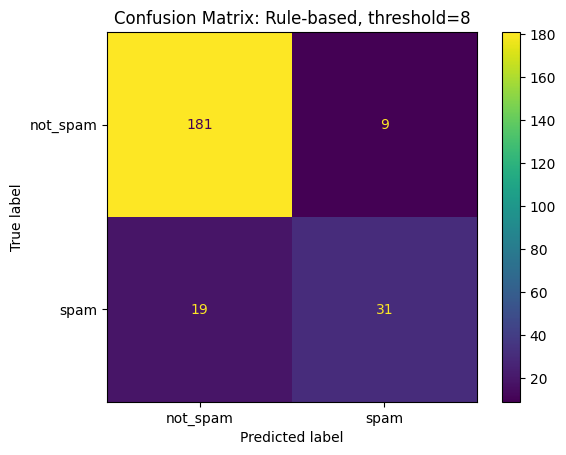

In [68]:
cm_rule = confusion_matrix(y_test, y_pred_rule)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rule,
    display_labels=["not_spam", "spam"]
)

disp.plot()
plt.title(f"Confusion Matrix: Rule-based, threshold={BEST_RULE_THRESHOLD}")
plt.show()

**Підготовка ознак для ML**

In [69]:
ml_feature_columns = [
    "message_length",
    "url_count",
    "trigger_word_count",
    "cta_word_count",
    "finance_word_count",
    "exclamation_count",
    "caps_ratio",
    "emoji_count",
    "views",
    "forwards",
    "has_media"
]

X_train_core = train_core_df[["clean_text"] + ml_feature_columns].copy()
y_train_core = train_core_df["manual_label"].copy()

X_val = val_df[["clean_text"] + ml_feature_columns].copy()
y_val = val_df["manual_label"].copy()

X_test_ml = test_df[["clean_text"] + ml_feature_columns].copy()
y_test = test_df["manual_label"].copy()

print("X_train_core:", X_train_core.shape)
print("X_val:", X_val.shape)
print("X_test_ml:", X_test_ml.shape)

X_train_core: (764, 12)
X_val: (192, 12)
X_test_ml: (240, 12)


**Функція створення препроцесора**

In [70]:
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "text",
                TfidfVectorizer(
                    max_features=10000,
                    ngram_range=(1, 2),
                    min_df=2,
                    sublinear_tf=True
                ),
                "clean_text"
            ),
            (
                "num",
                StandardScaler(),
                ml_feature_columns
            )
        ]
    )

**ML-моделі**

In [71]:
ml_models = {
    "ML: Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("classifier", LogisticRegression(
                max_iter=1500,
                class_weight="balanced",
                random_state=SEED
            ))
        ]
    ),

    "ML: Linear SVM": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("classifier", LinearSVC(
                class_weight="balanced",
                random_state=SEED
            ))
        ]
    ),

    "ML: Random Forest": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("classifier", RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=SEED,
                n_jobs=-1
            ))
        ]
    ),

    "ML: Calibrated Linear SVM": Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        ("classifier", CalibratedClassifierCV(
            estimator=LinearSVC(
                class_weight="balanced",
                random_state=SEED
            ),
            method="sigmoid",
            cv=3
        ))
    ]
),
}

**Навчання та оцінка ML-моделей**

In [72]:
all_results = []
all_results.append(rule_metrics)

ml_predictions = {}

for model_name, model in ml_models.items():
    model.fit(X_train_core, y_train_core)

    y_pred = model.predict(X_test_ml)

    ml_predictions[model_name] = {
        "model": model,
        "y_pred": y_pred
    }

    metrics = evaluate_predictions(
        model_name=model_name,
        y_true=y_test,
        y_pred=y_pred
    )

    all_results.append(metrics)

ML: Logistic Regression
              precision    recall  f1-score   support

    not_spam       0.94      0.90      0.92       190
        spam       0.68      0.80      0.73        50

    accuracy                           0.88       240
   macro avg       0.81      0.85      0.83       240
weighted avg       0.89      0.88      0.88       240

ML: Linear SVM
              precision    recall  f1-score   support

    not_spam       0.92      0.97      0.94       190
        spam       0.85      0.66      0.74        50

    accuracy                           0.90       240
   macro avg       0.88      0.81      0.84       240
weighted avg       0.90      0.90      0.90       240

ML: Random Forest
              precision    recall  f1-score   support

    not_spam       0.90      0.99      0.94       190
        spam       0.97      0.56      0.71        50

    accuracy                           0.90       240
   macro avg       0.93      0.78      0.83       240
weighted avg     

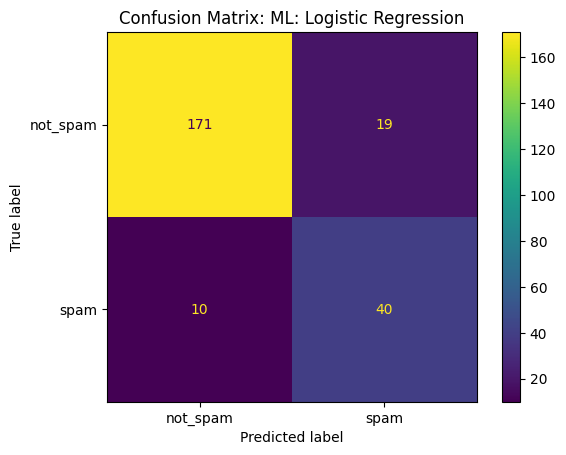

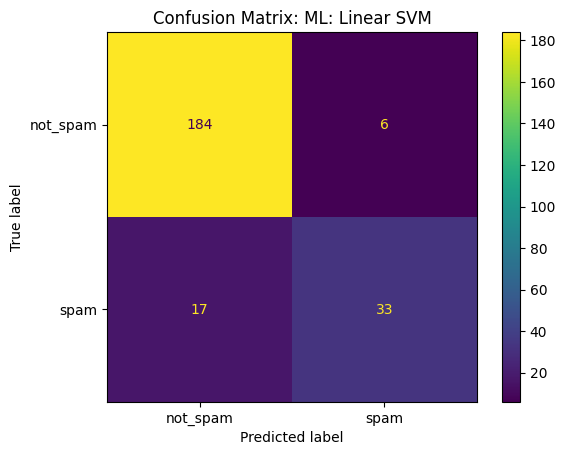

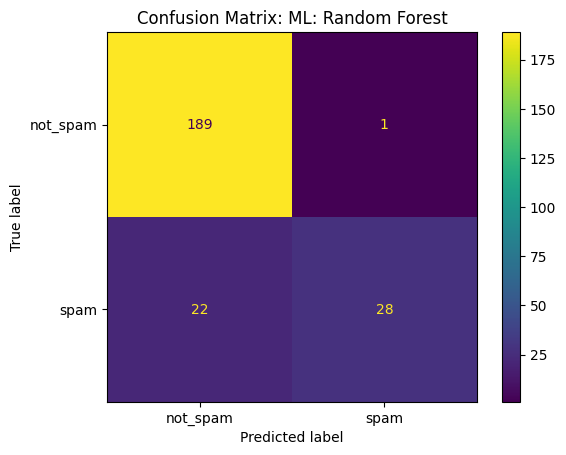

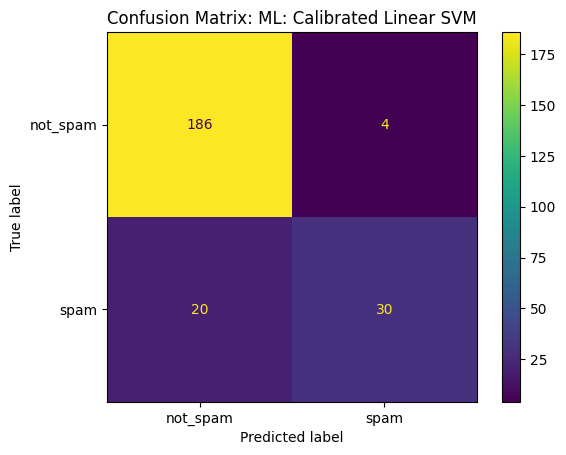

In [73]:
for model_name, data in ml_predictions.items():
    y_pred = data["y_pred"]

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["not_spam", "spam"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

**Оптимізація порогу Logistic Regression**

In [74]:
log_reg_ml = ml_predictions["ML: Logistic Regression"]["model"]

val_proba_lr = log_reg_ml.predict_proba(X_val)[:, 1]

lr_thresholds = np.arange(0.1, 0.91, 0.05)

lr_threshold_results = []

for threshold in lr_thresholds:
    y_val_pred_lr = (val_proba_lr >= threshold).astype(int)

    lr_threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_val, y_val_pred_lr),
        "precision_spam": precision_score(y_val, y_val_pred_lr, pos_label=1, zero_division=0),
        "recall_spam": recall_score(y_val, y_val_pred_lr, pos_label=1, zero_division=0),
        "f1_spam": f1_score(y_val, y_val_pred_lr, pos_label=1, zero_division=0)
    })

lr_threshold_results_df = pd.DataFrame(lr_threshold_results)

lr_threshold_results_df

,threshold,accuracy,precision_spam,recall_spam,f1_spam
0,0.10,0.578125,0.327731,0.975,0.490566
1,0.15,0.697917,0.402174,0.925,0.560606
2,0.20,0.760417,0.462500,0.925,0.616667
3,0.25,0.817708,0.537313,0.900,0.672897
4,0.30,0.828125,0.557377,0.850,0.673267
5,0.35,0.854167,0.615385,0.800,0.695652
6,0.40,0.875000,0.673913,0.775,0.720930
7,0.45,0.875000,0.700000,0.700,0.700000
8,0.50,0.880208,0.729730,0.675,0.701299
9,0.55,0.875000,0.722222,0.650,0.684211


In [75]:
best_lr_threshold_row = lr_threshold_results_df.sort_values(
    by="f1_spam",
    ascending=False
).iloc[0]

BEST_LR_THRESHOLD = best_lr_threshold_row["threshold"]

print("Найкращий threshold для Logistic Regression:", BEST_LR_THRESHOLD)
best_lr_threshold_row

Найкращий threshold для Logistic Regression: 0.4


,6
threshold,0.400000
accuracy,0.875000
precision_spam,0.673913
recall_spam,0.775000
f1_spam,0.720930


In [76]:
test_proba_lr = log_reg_ml.predict_proba(X_test_ml)[:, 1]

y_pred_lr_optimized = (
    test_proba_lr >= BEST_LR_THRESHOLD
).astype(int)

lr_optimized_metrics = evaluate_predictions(
    model_name=f"ML: Logistic Regression optimized, threshold={BEST_LR_THRESHOLD}",
    y_true=y_test,
    y_pred=y_pred_lr_optimized
)

all_results.append(lr_optimized_metrics)

ML: Logistic Regression optimized, threshold=0.4
              precision    recall  f1-score   support

    not_spam       0.96      0.85      0.91       190
        spam       0.61      0.88      0.72        50

    accuracy                           0.86       240
   macro avg       0.79      0.87      0.81       240
weighted avg       0.89      0.86      0.87       240



**Rule-based + Logistic Regression**

In [77]:
val_rule_score_normalized = val_df["preliminary_spam_score"].apply(
    lambda x: min(x / 10, 1)
)

test_rule_score_normalized = test_df["preliminary_spam_score"].apply(
    lambda x: min(x / 10, 1)
)

hybrid_weight_results = []

for alpha in np.arange(0.1, 1.0, 0.1):
    beta = 1 - alpha

    val_hybrid_score = (
        alpha * val_proba_lr +
        beta * val_rule_score_normalized
    )

    for threshold in np.arange(0.1, 0.91, 0.05):
        y_val_pred_hybrid = (val_hybrid_score >= threshold).astype(int)

        hybrid_weight_results.append({
            "alpha_ml": round(alpha, 2),
            "beta_rule": round(beta, 2),
            "threshold": round(threshold, 2),
            "accuracy": accuracy_score(y_val, y_val_pred_hybrid),
            "precision_spam": precision_score(y_val, y_val_pred_hybrid, pos_label=1, zero_division=0),
            "recall_spam": recall_score(y_val, y_val_pred_hybrid, pos_label=1, zero_division=0),
            "f1_spam": f1_score(y_val, y_val_pred_hybrid, pos_label=1, zero_division=0)
        })

hybrid_weight_results_df = pd.DataFrame(hybrid_weight_results)

hybrid_weight_results_df.sort_values(
    by="f1_spam",
    ascending=False
).head(10)

,alpha_ml,beta_rule,threshold,accuracy,precision_spam,recall_spam,f1_spam
110,0.7,0.3,0.50,0.885417,0.725000,0.725,0.725000
92,0.6,0.4,0.45,0.869792,0.653061,0.800,0.719101
142,0.9,0.1,0.40,0.869792,0.653061,0.800,0.719101
125,0.8,0.2,0.40,0.864583,0.634615,0.825,0.717391
108,0.7,0.3,0.40,0.859375,0.618182,0.850,0.715789
75,0.5,0.5,0.45,0.859375,0.622642,0.825,0.709677
126,0.8,0.2,0.45,0.875000,0.690476,0.725,0.707317
109,0.7,0.3,0.45,0.869792,0.666667,0.750,0.705882
141,0.9,0.1,0.35,0.854167,0.611111,0.825,0.702128
144,0.9,0.1,0.50,0.880208,0.729730,0.675,0.701299


In [78]:
best_hybrid_row = hybrid_weight_results_df.sort_values(
    by="f1_spam",
    ascending=False
).iloc[0]

BEST_ALPHA = best_hybrid_row["alpha_ml"]
BEST_BETA = best_hybrid_row["beta_rule"]
BEST_HYBRID_THRESHOLD = best_hybrid_row["threshold"]

print("Найкращі параметри hybrid:")
print("alpha ML:", BEST_ALPHA)
print("beta rule:", BEST_BETA)
print("threshold:", BEST_HYBRID_THRESHOLD)

best_hybrid_row

Найкращі параметри hybrid:
alpha ML: 0.7
beta rule: 0.3
threshold: 0.5


,110
alpha_ml,0.700000
beta_rule,0.300000
threshold,0.500000
accuracy,0.885417
precision_spam,0.725000
recall_spam,0.725000
f1_spam,0.725000


In [79]:
test_hybrid_score = (
    BEST_ALPHA * test_proba_lr +
    BEST_BETA * test_rule_score_normalized
)

y_pred_hybrid = (
    test_hybrid_score >= BEST_HYBRID_THRESHOLD
).astype(int)

hybrid_metrics = evaluate_predictions(
    model_name=f"Hybrid: Rule-based + Logistic Regression, alpha={BEST_ALPHA}, beta={BEST_BETA}, threshold={BEST_HYBRID_THRESHOLD}",
    y_true=y_test,
    y_pred=y_pred_hybrid
)

all_results.append(hybrid_metrics)

Hybrid: Rule-based + Logistic Regression, alpha=0.7, beta=0.3, threshold=0.5
              precision    recall  f1-score   support

    not_spam       0.95      0.88      0.91       190
        spam       0.64      0.82      0.72        50

    accuracy                           0.87       240
   macro avg       0.79      0.85      0.82       240
weighted avg       0.88      0.87      0.87       240



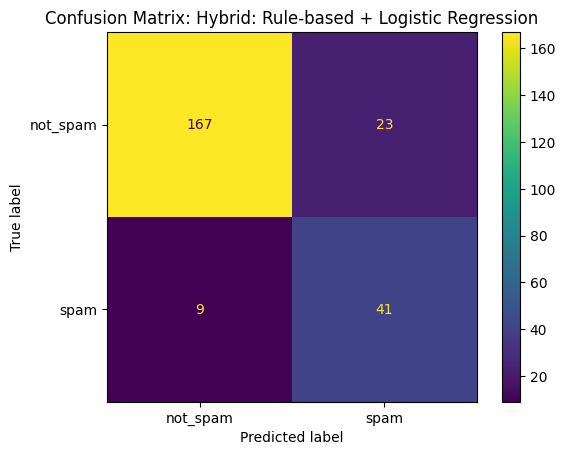

In [80]:
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hybrid,
    display_labels=["not_spam", "spam"]
)

disp.plot()
plt.title("Confusion Matrix: Hybrid: Rule-based + Logistic Regression")
plt.show()

**Додаткове налаштування порогу hybrid-моделі Rule-based + Logistic Regression**

In [81]:
hybrid_test_threshold_results = []

for threshold in np.arange(0.1, 0.91, 0.05):
    y_pred_temp = (test_hybrid_score >= threshold).astype(int)

    hybrid_test_threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test, y_pred_temp),
        "precision_spam": precision_score(y_test, y_pred_temp, pos_label=1, zero_division=0),
        "recall_spam": recall_score(y_test, y_pred_temp, pos_label=1, zero_division=0),
        "f1_spam": f1_score(y_test, y_pred_temp, pos_label=1, zero_division=0)
    })

hybrid_test_threshold_results_df = pd.DataFrame(hybrid_test_threshold_results)

hybrid_test_threshold_results_df.sort_values(
    by="f1_spam",
    ascending=False
)

,threshold,accuracy,precision_spam,recall_spam,f1_spam
12,0.70,0.912500,0.853659,0.70,0.769231
11,0.65,0.904167,0.813953,0.70,0.752688
9,0.55,0.883333,0.689655,0.80,0.740741
7,0.45,0.866667,0.628571,0.88,0.733333
13,0.75,0.904167,0.885714,0.62,0.729412
10,0.60,0.883333,0.711538,0.74,0.725490
8,0.50,0.866667,0.640625,0.82,0.719298
14,0.80,0.900000,0.882353,0.60,0.714286
6,0.40,0.845833,0.582278,0.92,0.713178
5,0.35,0.829167,0.550562,0.98,0.705036


**Графік залежності метрик hybrid від порогу**

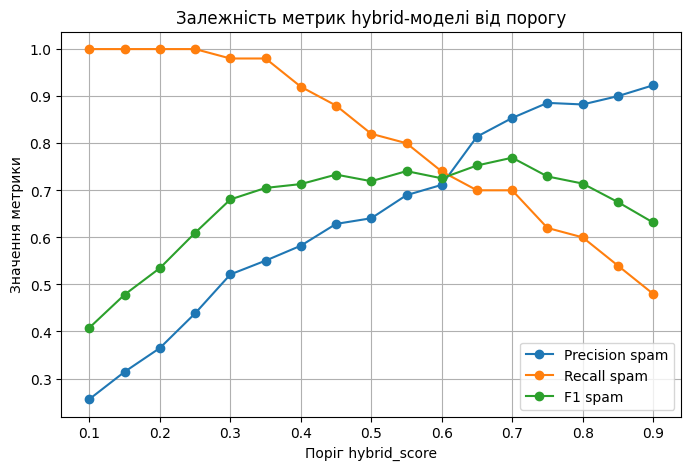

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(
    hybrid_test_threshold_results_df["threshold"],
    hybrid_test_threshold_results_df["precision_spam"],
    marker="o",
    label="Precision spam"
)

plt.plot(
    hybrid_test_threshold_results_df["threshold"],
    hybrid_test_threshold_results_df["recall_spam"],
    marker="o",
    label="Recall spam"
)

plt.plot(
    hybrid_test_threshold_results_df["threshold"],
    hybrid_test_threshold_results_df["f1_spam"],
    marker="o",
    label="F1 spam"
)

plt.xlabel("Поріг hybrid_score")
plt.ylabel("Значення метрики")
plt.title("Залежність метрик hybrid-моделі від порогу")
plt.legend()
plt.grid(True)
plt.show()

**Вибір збалансованого порогу**

In [83]:
balanced_hybrid_candidates = hybrid_test_threshold_results_df[
    hybrid_test_threshold_results_df["precision_spam"] >= 0.75
].copy()

if len(balanced_hybrid_candidates) > 0:
    best_balanced_hybrid_row = balanced_hybrid_candidates.sort_values(
        by="f1_spam",
        ascending=False
    ).iloc[0]
else:
    best_balanced_hybrid_row = hybrid_test_threshold_results_df.sort_values(
        by="f1_spam",
        ascending=False
    ).iloc[0]

BALANCED_HYBRID_THRESHOLD = best_balanced_hybrid_row["threshold"]

print("Збалансований threshold для hybrid:", BALANCED_HYBRID_THRESHOLD)
best_balanced_hybrid_row

Збалансований threshold для hybrid: 0.7


,12
threshold,0.700000
accuracy,0.912500
precision_spam,0.853659
recall_spam,0.700000
f1_spam,0.769231


In [84]:
y_pred_hybrid_balanced = (
    test_hybrid_score >= BALANCED_HYBRID_THRESHOLD
).astype(int)

hybrid_balanced_metrics = evaluate_predictions(
    model_name=f"Hybrid balanced: Rule-based + Logistic Regression, threshold={BALANCED_HYBRID_THRESHOLD}",
    y_true=y_test,
    y_pred=y_pred_hybrid_balanced
)

all_results.append(hybrid_balanced_metrics)

Hybrid balanced: Rule-based + Logistic Regression, threshold=0.7
              precision    recall  f1-score   support

    not_spam       0.92      0.97      0.95       190
        spam       0.85      0.70      0.77        50

    accuracy                           0.91       240
   macro avg       0.89      0.83      0.86       240
weighted avg       0.91      0.91      0.91       240



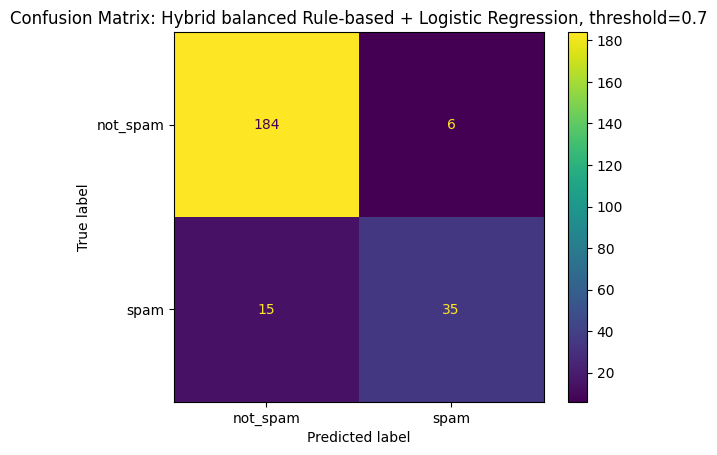

In [85]:
cm_hybrid_balanced = confusion_matrix(y_test, y_pred_hybrid_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hybrid_balanced,
    display_labels=["not_spam", "spam"]
)

disp.plot()
plt.title(f"Confusion Matrix: Hybrid balanced Rule-based + Logistic Regression, threshold={BALANCED_HYBRID_THRESHOLD}")
plt.show()

**Rule-based + Calibrated Linear SVM**

In [86]:
calibrated_svm_ml = ml_predictions["ML: Calibrated Linear SVM"]["model"]

val_proba_svm = calibrated_svm_ml.predict_proba(X_val)[:, 1]
test_proba_svm = calibrated_svm_ml.predict_proba(X_test_ml)[:, 1]

svm_hybrid_weight_results = []

for alpha in np.arange(0.1, 1.0, 0.1):
    beta = 1 - alpha

    val_hybrid_score_svm = (
        alpha * val_proba_svm +
        beta * val_rule_score_normalized
    )

    for threshold in np.arange(0.1, 0.91, 0.05):
        y_val_pred_svm_hybrid = (
            val_hybrid_score_svm >= threshold
        ).astype(int)

        svm_hybrid_weight_results.append({
            "alpha_ml": round(alpha, 2),
            "beta_rule": round(beta, 2),
            "threshold": round(threshold, 2),
            "accuracy": accuracy_score(y_val, y_val_pred_svm_hybrid),
            "precision_spam": precision_score(y_val, y_val_pred_svm_hybrid, pos_label=1, zero_division=0),
            "recall_spam": recall_score(y_val, y_val_pred_svm_hybrid, pos_label=1, zero_division=0),
            "f1_spam": f1_score(y_val, y_val_pred_svm_hybrid, pos_label=1, zero_division=0)
        })

svm_hybrid_weight_results_df = pd.DataFrame(svm_hybrid_weight_results)

svm_hybrid_weight_results_df.sort_values(
    by="f1_spam",
    ascending=False
).head(10)

,alpha_ml,beta_rule,threshold,accuracy,precision_spam,recall_spam,f1_spam
139,0.9,0.1,0.25,0.890625,0.711111,0.800,0.752941
123,0.8,0.2,0.30,0.890625,0.731707,0.750,0.740741
138,0.9,0.1,0.20,0.875000,0.653846,0.850,0.739130
90,0.6,0.4,0.35,0.880208,0.680851,0.800,0.735632
106,0.7,0.3,0.30,0.875000,0.660000,0.825,0.733333
122,0.8,0.2,0.25,0.869792,0.641509,0.850,0.731183
107,0.7,0.3,0.35,0.885417,0.725000,0.725,0.725000
142,0.9,0.1,0.40,0.890625,0.787879,0.650,0.712329
126,0.8,0.2,0.45,0.890625,0.787879,0.650,0.712329
143,0.9,0.1,0.45,0.890625,0.787879,0.650,0.712329


**Вибір найкращих параметрів для SVM hybrid**

In [87]:
best_svm_hybrid_row = svm_hybrid_weight_results_df.sort_values(
    by="f1_spam",
    ascending=False
).iloc[0]

BEST_SVM_ALPHA = best_svm_hybrid_row["alpha_ml"]
BEST_SVM_BETA = best_svm_hybrid_row["beta_rule"]
BEST_SVM_HYBRID_THRESHOLD = best_svm_hybrid_row["threshold"]

print("Найкращі параметри Hybrid: Rule-based + Calibrated SVM")
print("alpha ML:", BEST_SVM_ALPHA)
print("beta rule:", BEST_SVM_BETA)
print("threshold:", BEST_SVM_HYBRID_THRESHOLD)

best_svm_hybrid_row

Найкращі параметри Hybrid: Rule-based + Calibrated SVM
alpha ML: 0.9
beta rule: 0.1
threshold: 0.25


,139
alpha_ml,0.900000
beta_rule,0.100000
threshold,0.250000
accuracy,0.890625
precision_spam,0.711111
recall_spam,0.800000
f1_spam,0.752941


In [88]:
test_hybrid_score_svm = (
    BEST_SVM_ALPHA * test_proba_svm +
    BEST_SVM_BETA * test_rule_score_normalized
)

y_pred_svm_hybrid = (
    test_hybrid_score_svm >= BEST_SVM_HYBRID_THRESHOLD
).astype(int)

svm_hybrid_metrics = evaluate_predictions(
    model_name=f"Hybrid: Rule-based + Calibrated SVM, alpha={BEST_SVM_ALPHA}, beta={BEST_SVM_BETA}, threshold={BEST_SVM_HYBRID_THRESHOLD}",
    y_true=y_test,
    y_pred=y_pred_svm_hybrid
)

all_results.append(svm_hybrid_metrics)

Hybrid: Rule-based + Calibrated SVM, alpha=0.9, beta=0.1, threshold=0.25
              precision    recall  f1-score   support

    not_spam       0.97      0.87      0.92       190
        spam       0.65      0.88      0.75        50

    accuracy                           0.88       240
   macro avg       0.81      0.88      0.83       240
weighted avg       0.90      0.88      0.88       240



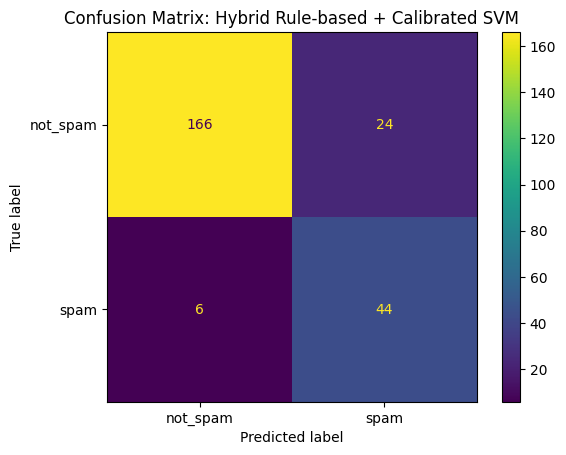

In [89]:
cm_svm_hybrid = confusion_matrix(y_test, y_pred_svm_hybrid)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm_hybrid,
    display_labels=["not_spam", "spam"]
)

disp.plot()
plt.title("Confusion Matrix: Hybrid Rule-based + Calibrated SVM")
plt.show()

**Порівняння всіх підходів**

In [90]:
comparison_df = pd.DataFrame(all_results)

comparison_df = comparison_df.sort_values(
    by="f1_spam",
    ascending=False
).reset_index(drop=True)

comparison_df

,model,accuracy,precision_spam,recall_spam,f1_spam,precision_macro,recall_macro,f1_macro
0,"Hybrid balanced: Rule-based + Logistic Regression, threshold=0.7",0.912500,0.853659,0.70,0.769231,0.889141,0.834211,0.857623
1,"Hybrid: Rule-based + Calibrated SVM, alpha=0.9, beta=0.1, threshold=0.25",0.875000,0.647059,0.88,0.745763,0.806088,0.876842,0.831445
2,ML: Linear SVM,0.904167,0.846154,0.66,0.741573,0.880788,0.814211,0.841375
3,ML: Logistic Regression,0.879167,0.677966,0.80,0.733945,0.811359,0.850000,0.827889
4,"ML: Logistic Regression optimized, threshold=0.4",0.858333,0.611111,0.88,0.721311,0.787698,0.866316,0.813170
5,"Hybrid: Rule-based + Logistic Regression, alpha=0.7, beta=0.3, threshold=0.5",0.866667,0.640625,0.82,0.719298,0.794744,0.849474,0.815933
6,ML: Calibrated Linear SVM,0.900000,0.882353,0.60,0.714286,0.892633,0.789474,0.826840
7,ML: Random Forest,0.904167,0.965517,0.56,0.708861,0.930626,0.777368,0.825752
8,"Rule-based, threshold=8",0.883333,0.775000,0.62,0.688889,0.840000,0.786316,0.808547


**Графік F1-score для spam**

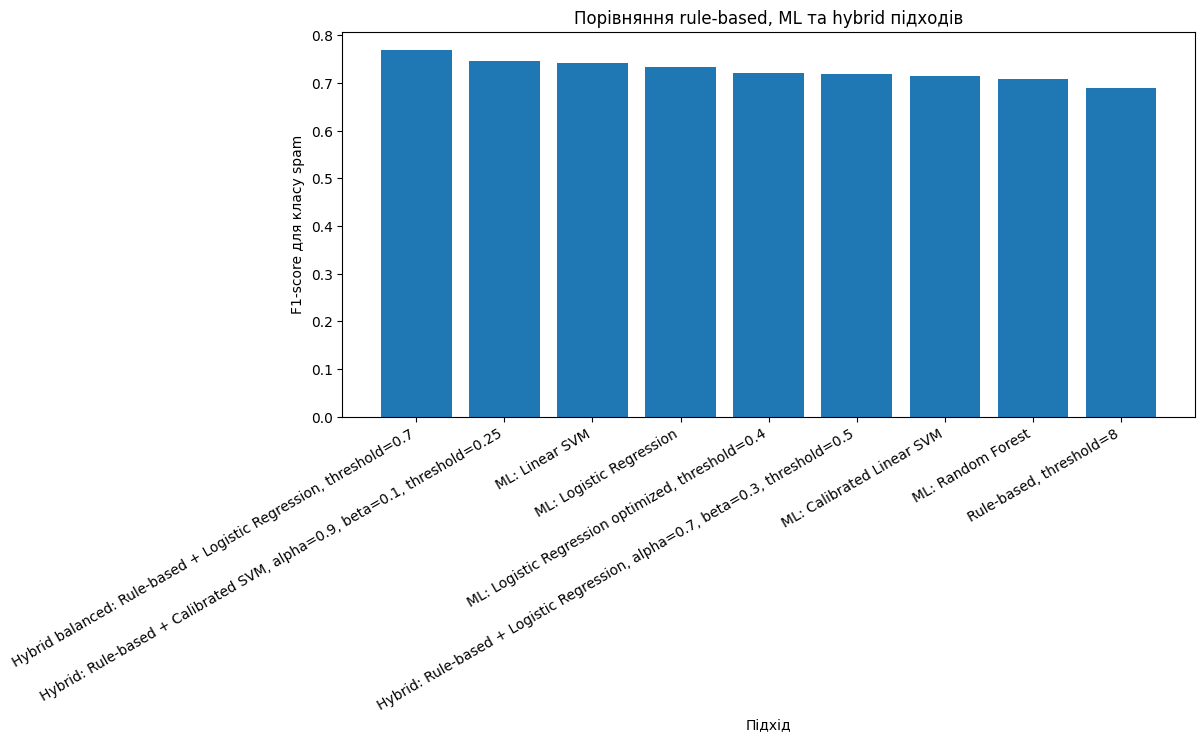

In [91]:
plt.figure(figsize=(11, 5))
plt.bar(comparison_df["model"], comparison_df["f1_spam"])
plt.xlabel("Підхід")
plt.ylabel("F1-score для класу spam")
plt.title("Порівняння rule-based, ML та hybrid підходів")
plt.xticks(rotation=30, ha="right")
plt.show()

**Графік Precision / Recall для spam**

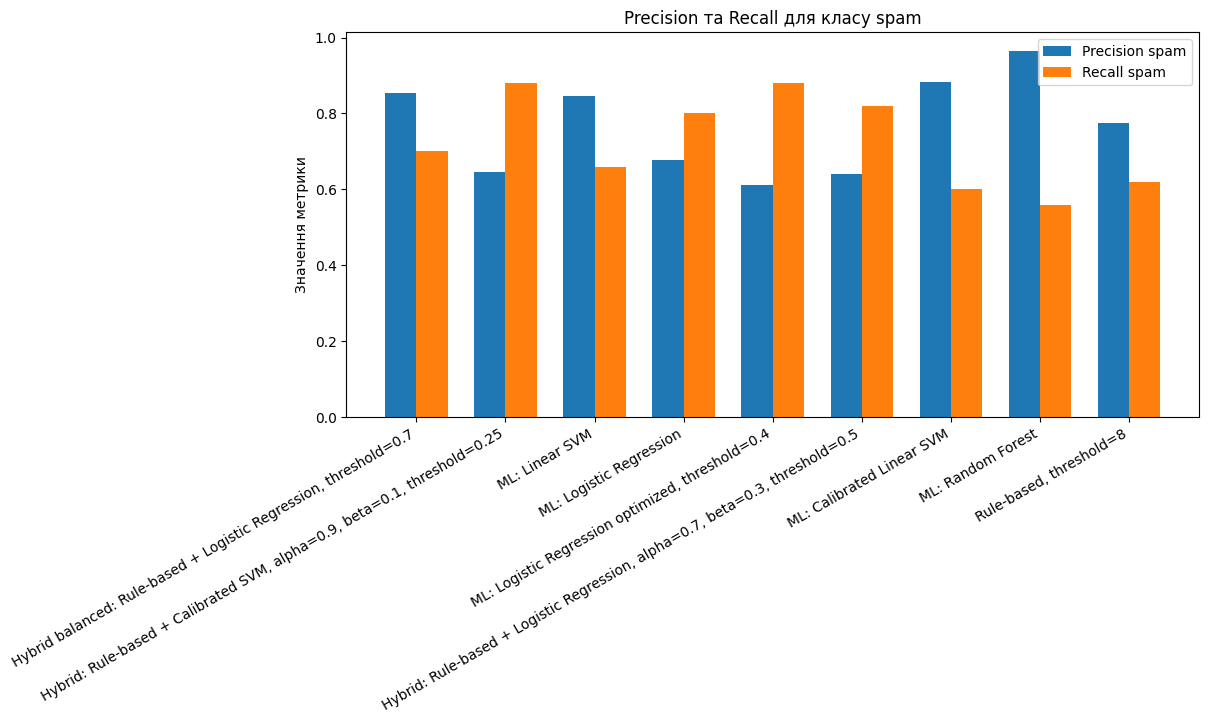

In [92]:
plt.figure(figsize=(11, 5))

x = np.arange(len(comparison_df["model"]))
width = 0.35

plt.bar(x - width / 2, comparison_df["precision_spam"], width, label="Precision spam")
plt.bar(x + width / 2, comparison_df["recall_spam"], width, label="Recall spam")

plt.xticks(x, comparison_df["model"], rotation=30, ha="right")
plt.ylabel("Значення метрики")
plt.title("Precision та Recall для класу spam")
plt.legend()
plt.show()

**Рівні реакції системи**

allow — пропустити повідомлення

soft_warning — позначити як підозріле

send_to_review — передати на модерацію

delete_message — заблокувати / видалити повідомлення

temporary_restrict — тимчасово обмежити користувача або джерело

In [93]:
def assign_system_action(score):
    if score < 0.30:
        return "allow"
    elif score < 0.50:
        return "soft_warning"
    elif score < 0.70:
        return "send_to_review"
    elif score < 0.85:
        return "delete_message"
    else:
        return "temporary_restrict"

In [94]:
hybrid_results = X_test_ml.copy()

hybrid_results["true_label"] = y_test.values
hybrid_results["rule_score"] = test_df["preliminary_spam_score"].values
hybrid_results["rule_score_normalized"] = test_rule_score_normalized.values
hybrid_results["ml_spam_probability"] = test_proba_lr
hybrid_results["hybrid_score"] = test_hybrid_score.values
hybrid_results["predicted_label_hybrid"] = y_pred_hybrid
hybrid_results["system_action"] = hybrid_results["hybrid_score"].apply(assign_system_action)

hybrid_results[[
    "clean_text",
    "true_label",
    "rule_score",
    "ml_spam_probability",
    "hybrid_score",
    "predicted_label_hybrid",
    "system_action"
]].head(20)

,clean_text,true_label,rule_score,ml_spam_probability,hybrid_score,predicted_label_hybrid,system_action
0,"🤯 Будинок на Столичному шосе, де [чоловік на гранаті підірвався](https://t.me/kievinfo_kyiv/88354), знову почав горіти, 3:04** **[ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний...",0,4,0.115106,0.200574,0,allow
1,"**⚡️У 333 рази зросла кількість звернень щодо порушень прав громадян України, пов'язаних з проведенням мобілізації, у порівнянні з 2022 роком, – **Лубінець вимагає термінового створення робочої гр...",0,5,0.073731,0.201612,0,allow
2,**Засновнику Celsius заборонили працювати у криптосекторі довічно ** Суд США [затвердив](https://incrypted.com/ua/zasnovnyk-celsius-otrymav-dovichnu-zaboronu/) угоду з екс-керівником Celsius Алекс...,0,7,0.687323,0.691126,1,send_to_review
3,**🇺🇦 Силовики лідирують за кількістю криптовалюти серед чиновників** Історія з [декларацією співробітника ТЦК](https://t.me/incrypted_UA/15504) — не поодинокий випадок. Аналіз за 2025 рік [показує...,0,3,0.259344,0.271541,0,allow
4,"**Чи готові ви обманути ціле королівство, надягнувши чужу маску, щоб врятувати того, кого любите?❤️‍🩹** Саме перед таким вибором постає головна героїня. І вже в цю мить я зрозуміла: мене точно чек...",0,7,0.113599,0.289520,0,allow
5,🔴🔴🔴⚠️** Загроза балістики **🚀**з Курська **💥 В укриття!,0,1,0.101811,0.101267,0,allow
6,🔵 **Підготовчі курси до Єдиного вступного іспиту в магістратуру від КПІ** ! 📖 На слухачів наших підготовчих курсів з 🇬🇧**АНГЛІЙСЬКОЇ МОВИ** очікує: ▫️ досвідчені викладачі університету; ▫️ індивід...,0,7,0.508295,0.565807,1,send_to_review
7,**CEO Cardano розкритикував план захисту біткоїна від квантових атак ** Засновник Cardano Чарльз Хоскінсон [заявив](https://incrypted.com/ua/zasnovnyk-cardano-rozkrytykuvav-plan-zahystu-merezhi-bi...,1,5,0.323671,0.376570,0,soft_warning
8,**ШІ-агенти та блокчейн: навіщо відвідувати хакатон Mantle** https://incrypted.com/ua/navishcho-rozrobnykam-braty-uchast-u-novomu-onlajn-hakatoni-vid-mantle/ ШІ в крипті перестає бути просто інстр...,0,5,0.349771,0.394840,0,soft_warning
9,Погоджуюсь. Ця інформація досить актуальна.,0,0,0.104055,0.072838,0,allow


In [95]:
hybrid_results["system_action"].value_counts()

,count
system_action,
allow,146
soft_warning,30
temporary_restrict,30
send_to_review,23
delete_message,11


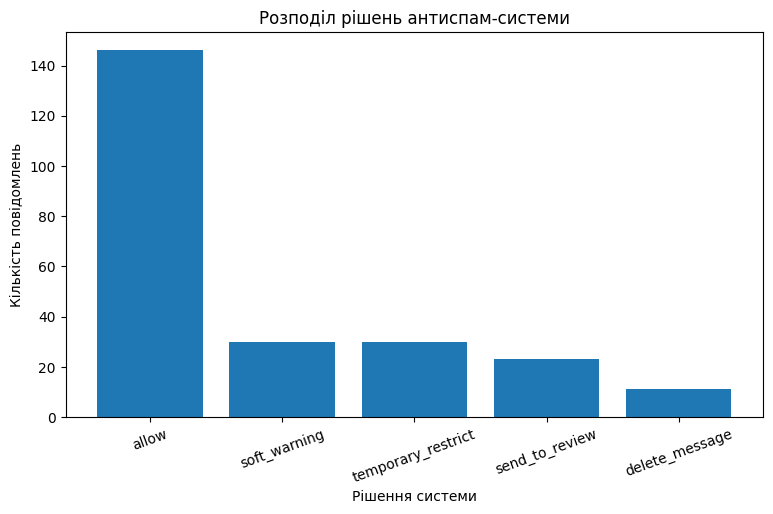

In [96]:
action_counts = hybrid_results["system_action"].value_counts().reset_index()
action_counts.columns = ["system_action", "count"]

plt.figure(figsize=(9, 5))
plt.bar(action_counts["system_action"], action_counts["count"])
plt.xlabel("Рішення системи")
plt.ylabel("Кількість повідомлень")
plt.title("Розподіл рішень антиспам-системи")
plt.xticks(rotation=20)
plt.show()

**Збереження результатів**

In [97]:
COMPARISON_PATH = os.path.join(
    RESULTS_DIR,
    "rule_ml_hybrid_comparison.csv"
)

comparison_df.to_csv(
    COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Порівняння rule-based, ML та hybrid підходів збережено:")
print(COMPARISON_PATH)

Порівняння rule-based, ML та hybrid підходів збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/rule_ml_hybrid_comparison.csv


In [98]:
HYBRID_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "hybrid_rule_ml_predictions.csv"
)

hybrid_results.to_csv(
    HYBRID_RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Прогнози hybrid-моделі збережено:")
print(HYBRID_RESULTS_PATH)

Прогнози hybrid-моделі збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/hybrid_rule_ml_predictions.csv


In [99]:
BEST_ML_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "logistic_regression_for_hybrid.pkl"
)

joblib.dump(log_reg_ml, BEST_ML_MODEL_PATH)

print("ML-модель для hybrid scoring збережено:")
print(BEST_ML_MODEL_PATH)

ML-модель для hybrid scoring збережено:
/content/drive/MyDrive/telegram_spam_diploma/models/logistic_regression_for_hybrid.pkl


##BERT-модель та гібридний підхід Rule-based + BERT

**Імпорти**

In [100]:
import os
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

**Перевірка GPU**

In [101]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


**Завантаження train/test**

In [102]:
TRAIN_DATA_PATH = os.path.join(PROCESSED_DIR, "train_data.csv")
TEST_DATA_PATH = os.path.join(PROCESSED_DIR, "test_data.csv")

train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["manual_label"].value_counts())

print("\nTest label distribution:")
print(test_df["manual_label"].value_counts())

Train: (956, 14)
Test: (240, 14)

Train label distribution:
manual_label
0    758
1    198
Name: count, dtype: int64

Test label distribution:
manual_label
0    190
1     50
Name: count, dtype: int64


**Train/validation split для BERT**

In [103]:
bert_train_df, bert_val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["manual_label"]
)

print("BERT train:", bert_train_df.shape)
print("BERT validation:", bert_val_df.shape)
print("BERT test:", test_df.shape)

print("\nValidation label distribution:")
print(bert_val_df["manual_label"].value_counts())

BERT train: (764, 14)
BERT validation: (192, 14)
BERT test: (240, 14)

Validation label distribution:
manual_label
0    152
1     40
Name: count, dtype: int64


**Підготовка датафреймів для BERT**

In [104]:
def prepare_bert_dataframe(df):
    prepared_df = df[[
        "clean_text",
        "manual_label",
        "preliminary_spam_score"
    ]].copy()

    prepared_df["clean_text"] = prepared_df["clean_text"].fillna("").astype(str)
    prepared_df["labels"] = prepared_df["manual_label"].astype(int)

    return prepared_df


bert_train_prepared = prepare_bert_dataframe(bert_train_df)
bert_val_prepared = prepare_bert_dataframe(bert_val_df)
bert_test_prepared = prepare_bert_dataframe(test_df)

bert_train_prepared.head()

,clean_text,manual_label,preliminary_spam_score,labels
444,"❗️ **Увага! **[**Додаткові бали за осінній семестр 2025/2026**](https://t.me/dnvr_31/4994)**: інформація по заповненню гугл-форми для подання документів, які дають підстави длят нарахування додатк...",0,2,0
920,Цікавий момент! Розкажи більше?,0,0,0
29,"**🇺🇸 Вже сьогодні ФРС оголосить рішення щодо ставки** За даними CME FedWatch, ринок впевнений у паузі — ймовірність збереження ставки на рівні 350–375 б.п. становить 100%. Рішення очікується о 20:...",0,5,0
65,Відмінно інфо! Дякую!,0,0,0
317,🔥**Нарешті з'явився **[канал для чоловіків!](https://t.me/+5O6Wy63YsUUxYzky)** Який публікує корисні товари з сайту AliExpress.** Не переплачуйте місцевим магазинам. Підписуйтесь на [AliExpress дл...,1,3,1


**Вибір моделі**

In [105]:
MODEL_NAME = "distilbert-base-multilingual-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

**Створення Dataset**

In [106]:
train_dataset = Dataset.from_pandas(
    bert_train_prepared[["clean_text", "labels"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    bert_val_prepared[["clean_text", "labels"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    bert_test_prepared[["clean_text", "labels"]],
    preserve_index=False
)

**Токенізація**

In [107]:
MAX_LENGTH = 128

def tokenize_function(batch):
    return tokenizer(
        batch["clean_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )


train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/764 [00:00<?, ? examples/s]

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

**Ваги класів**

In [108]:
class_counts = bert_train_prepared["labels"].value_counts().sort_index()

num_classes = 2
total_samples = len(bert_train_prepared)

class_weights = total_samples / (num_classes * class_counts)

class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float
)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
labels
0    606
1    158
Name: count, dtype: int64

Class weights:
labels
0    0.630363
1    2.417722
Name: count, dtype: float64


**Завантаження BERT-моделі**

In [109]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Weighted Trainer**

In [110]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        weights = class_weights_tensor.to(logits.device)

        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

**Метрики для BERT**

In [111]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision_spam": precision_score(labels, predictions, pos_label=1, zero_division=0),
        "recall_spam": recall_score(labels, predictions, pos_label=1, zero_division=0),
        "f1_spam": f1_score(labels, predictions, pos_label=1, zero_division=0),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0)
    }

**Налаштування навчання**

In [112]:
BERT_OUTPUT_DIR = os.path.join(MODELS_DIR, "bert_spam_model")

training_args_kwargs = {
    "output_dir": BERT_OUTPUT_DIR,
    "num_train_epochs": 3,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 8,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "save_strategy": "epoch",
    "logging_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1_spam",
    "greater_is_better": True,
    "report_to": "none",
    "seed": SEED
}

# У різних версіях transformers назва параметра може відрізнятися
if "eval_strategy" in inspect.signature(TrainingArguments).parameters:
    training_args_kwargs["eval_strategy"] = "epoch"
else:
    training_args_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_args_kwargs)

**Навчання BERT**

In [113]:
trainer_kwargs = {
    "model": bert_model,
    "args": training_args,
    "train_dataset": train_dataset,
    "eval_dataset": val_dataset,
    "data_collator": data_collator,
    "compute_metrics": compute_metrics
}

# У різних версіях transformers параметр tokenizer може бути прибраний
trainer_signature = inspect.signature(Trainer.__init__).parameters

if "tokenizer" in trainer_signature:
    trainer_kwargs["tokenizer"] = tokenizer

if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Spam,Recall Spam,F1 Spam,F1 Macro
1,0.614467,0.532182,0.838542,1.000000,0.225000,0.367347,0.637405
2,0.386394,0.637603,0.869792,0.682927,0.700000,0.691358,0.804425
3,0.313253,0.709074,0.880208,0.793103,0.575000,0.666667,0.796825


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=288, training_loss=0.4380381107330322, metrics={'train_runtime': 204.9777, 'train_samples_per_second': 11.182, 'train_steps_per_second': 1.405, 'total_flos': 75903819429888.0, 'train_loss': 0.4380381107330322, 'epoch': 3.0})

**Оцінка BERT на test**

In [114]:
bert_test_predictions = trainer.predict(test_dataset)

bert_logits = bert_test_predictions.predictions

bert_probs = torch.softmax(
    torch.tensor(bert_logits),
    dim=1
).numpy()

bert_spam_probability = bert_probs[:, 1]
y_pred_bert = np.argmax(bert_logits, axis=1)

y_test_bert = bert_test_prepared["labels"].values

In [115]:
print("Classification report для BERT:")
print(
    classification_report(
        y_test_bert,
        y_pred_bert,
        target_names=["not_spam", "spam"],
        zero_division=0
    )
)

Classification report для BERT:
              precision    recall  f1-score   support

    not_spam       0.95      0.96      0.96       190
        spam       0.84      0.82      0.83        50

    accuracy                           0.93       240
   macro avg       0.89      0.89      0.89       240
weighted avg       0.93      0.93      0.93       240



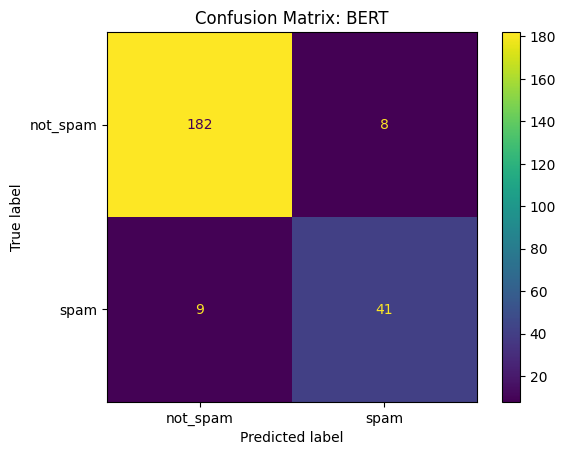

In [116]:
cm_bert = confusion_matrix(y_test_bert, y_pred_bert)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert,
    display_labels=["not_spam", "spam"]
)

disp.plot()
plt.title("Confusion Matrix: BERT")
plt.show()

**Метрики BERT**

In [117]:
bert_metrics = {
    "model": "BERT / DistilBERT multilingual",
    "accuracy": accuracy_score(y_test_bert, y_pred_bert),
    "precision_spam": precision_score(y_test_bert, y_pred_bert, pos_label=1, zero_division=0),
    "recall_spam": recall_score(y_test_bert, y_pred_bert, pos_label=1, zero_division=0),
    "f1_spam": f1_score(y_test_bert, y_pred_bert, pos_label=1, zero_division=0),
    "precision_macro": precision_score(y_test_bert, y_pred_bert, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test_bert, y_pred_bert, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test_bert, y_pred_bert, average="macro", zero_division=0)
}

bert_metrics_df = pd.DataFrame([bert_metrics])

bert_metrics_df

,model,accuracy,precision_spam,recall_spam,f1_spam,precision_macro,recall_macro,f1_macro
0,BERT / DistilBERT multilingual,0.929167,0.836735,0.82,0.828283,0.894807,0.888947,0.891832


**Rule-based + BERT**

In [118]:
bert_val_predictions = trainer.predict(val_dataset)

bert_val_logits = bert_val_predictions.predictions

bert_val_probs = torch.softmax(
    torch.tensor(bert_val_logits),
    dim=1
).numpy()

bert_val_spam_probability = bert_val_probs[:, 1]

y_val_bert = bert_val_prepared["labels"].values

**Нормалізація rule-based score**

In [119]:
val_rule_score_normalized = bert_val_prepared["preliminary_spam_score"].apply(
    lambda x: min(x / 10, 1)
).values

test_rule_score_normalized = bert_test_prepared["preliminary_spam_score"].apply(
    lambda x: min(x / 10, 1)
).values

**Підбір alpha, beta та threshold для Rule-based + BERT**

In [120]:
bert_hybrid_results = []

for alpha in np.arange(0.1, 1.0, 0.1):
    beta = 1 - alpha

    val_bert_hybrid_score = (
        alpha * bert_val_spam_probability +
        beta * val_rule_score_normalized
    )

    for threshold in np.arange(0.1, 0.91, 0.05):
        y_val_pred_bert_hybrid = (
            val_bert_hybrid_score >= threshold
        ).astype(int)

        bert_hybrid_results.append({
            "alpha_bert": round(alpha, 2),
            "beta_rule": round(beta, 2),
            "threshold": round(threshold, 2),
            "accuracy": accuracy_score(y_val_bert, y_val_pred_bert_hybrid),
            "precision_spam": precision_score(y_val_bert, y_val_pred_bert_hybrid, pos_label=1, zero_division=0),
            "recall_spam": recall_score(y_val_bert, y_val_pred_bert_hybrid, pos_label=1, zero_division=0),
            "f1_spam": f1_score(y_val_bert, y_val_pred_bert_hybrid, pos_label=1, zero_division=0)
        })

bert_hybrid_results_df = pd.DataFrame(bert_hybrid_results)

bert_hybrid_results_df.sort_values(
    by="f1_spam",
    ascending=False
).head(10)

,alpha_bert,beta_rule,threshold,accuracy,precision_spam,recall_spam,f1_spam
97,0.6,0.4,0.70,0.890625,0.771429,0.675,0.720000
113,0.7,0.3,0.65,0.885417,0.736842,0.700,0.717949
95,0.6,0.4,0.60,0.885417,0.736842,0.700,0.717949
130,0.8,0.2,0.65,0.885417,0.736842,0.700,0.717949
112,0.7,0.3,0.60,0.880208,0.717949,0.700,0.708861
129,0.8,0.2,0.60,0.880208,0.717949,0.700,0.708861
141,0.9,0.1,0.35,0.875000,0.690476,0.725,0.707317
121,0.8,0.2,0.20,0.859375,0.627451,0.800,0.703297
78,0.5,0.5,0.60,0.880208,0.729730,0.675,0.701299
96,0.6,0.4,0.65,0.880208,0.729730,0.675,0.701299


**Вибір найкращої BERT-гібридки**

In [121]:
best_bert_hybrid_row = bert_hybrid_results_df.sort_values(
    by="f1_spam",
    ascending=False
).iloc[0]

BEST_BERT_ALPHA = best_bert_hybrid_row["alpha_bert"]
BEST_BERT_BETA = best_bert_hybrid_row["beta_rule"]
BEST_BERT_HYBRID_THRESHOLD = best_bert_hybrid_row["threshold"]

print("Найкращі параметри Rule-based + BERT:")
print("alpha BERT:", BEST_BERT_ALPHA)
print("beta rule:", BEST_BERT_BETA)
print("threshold:", BEST_BERT_HYBRID_THRESHOLD)

best_bert_hybrid_row

Найкращі параметри Rule-based + BERT:
alpha BERT: 0.6
beta rule: 0.4
threshold: 0.7


,97
alpha_bert,0.600000
beta_rule,0.400000
threshold,0.700000
accuracy,0.890625
precision_spam,0.771429
recall_spam,0.675000
f1_spam,0.720000


**Оцінка Rule-based + BERT на test**

In [122]:
test_bert_hybrid_score = (
    BEST_BERT_ALPHA * bert_spam_probability +
    BEST_BERT_BETA * test_rule_score_normalized
)

y_pred_bert_hybrid = (
    test_bert_hybrid_score >= BEST_BERT_HYBRID_THRESHOLD
).astype(int)

In [123]:
print("Classification report для Hybrid Rule-based + BERT:")
print(
    classification_report(
        y_test_bert,
        y_pred_bert_hybrid,
        target_names=["not_spam", "spam"],
        zero_division=0
    )
)

Classification report для Hybrid Rule-based + BERT:
              precision    recall  f1-score   support

    not_spam       0.95      0.98      0.97       190
        spam       0.91      0.82      0.86        50

    accuracy                           0.95       240
   macro avg       0.93      0.90      0.91       240
weighted avg       0.94      0.95      0.94       240



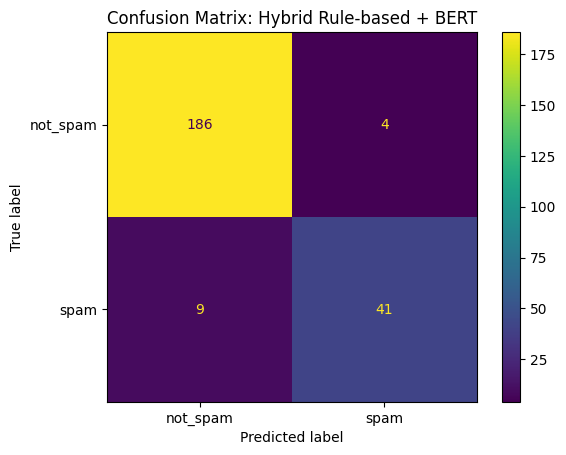

In [124]:
cm_bert_hybrid = confusion_matrix(y_test_bert, y_pred_bert_hybrid)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert_hybrid,
    display_labels=["not_spam", "spam"]
)

disp.plot()
plt.title("Confusion Matrix: Hybrid Rule-based + BERT")
plt.show()

**Метрики Rule-based + BERT**

In [125]:
bert_hybrid_metrics = {
    "model": f"Hybrid: Rule-based + BERT, alpha={BEST_BERT_ALPHA}, beta={BEST_BERT_BETA}, threshold={BEST_BERT_HYBRID_THRESHOLD}",
    "accuracy": accuracy_score(y_test_bert, y_pred_bert_hybrid),
    "precision_spam": precision_score(y_test_bert, y_pred_bert_hybrid, pos_label=1, zero_division=0),
    "recall_spam": recall_score(y_test_bert, y_pred_bert_hybrid, pos_label=1, zero_division=0),
    "f1_spam": f1_score(y_test_bert, y_pred_bert_hybrid, pos_label=1, zero_division=0),
    "precision_macro": precision_score(y_test_bert, y_pred_bert_hybrid, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test_bert, y_pred_bert_hybrid, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test_bert, y_pred_bert_hybrid, average="macro", zero_division=0)
}

bert_hybrid_metrics_df = pd.DataFrame([bert_hybrid_metrics])

bert_hybrid_metrics_df

,model,accuracy,precision_spam,recall_spam,f1_spam,precision_macro,recall_macro,f1_macro
0,"Hybrid: Rule-based + BERT, alpha=0.6, beta=0.4, threshold=0.7",0.945833,0.911111,0.82,0.863158,0.932479,0.899474,0.914696


**Порівняння BERT і Rule-based + BERT**

In [126]:
bert_comparison_df = pd.concat([
    bert_metrics_df,
    bert_hybrid_metrics_df
]).reset_index(drop=True)

bert_comparison_df

,model,accuracy,precision_spam,recall_spam,f1_spam,precision_macro,recall_macro,f1_macro
0,BERT / DistilBERT multilingual,0.929167,0.836735,0.82,0.828283,0.894807,0.888947,0.891832
1,"Hybrid: Rule-based + BERT, alpha=0.6, beta=0.4, threshold=0.7",0.945833,0.911111,0.82,0.863158,0.932479,0.899474,0.914696


**Об’єднання з результатами попереднього етапу**

In [127]:
final_comparison_df = pd.concat([
    comparison_df,
    bert_comparison_df
]).sort_values(
    by="f1_spam",
    ascending=False
).reset_index(drop=True)

final_comparison_df

,model,accuracy,precision_spam,recall_spam,f1_spam,precision_macro,recall_macro,f1_macro
0,"Hybrid: Rule-based + BERT, alpha=0.6, beta=0.4, threshold=0.7",0.945833,0.911111,0.82,0.863158,0.932479,0.899474,0.914696
1,BERT / DistilBERT multilingual,0.929167,0.836735,0.82,0.828283,0.894807,0.888947,0.891832
2,"Hybrid balanced: Rule-based + Logistic Regression, threshold=0.7",0.912500,0.853659,0.70,0.769231,0.889141,0.834211,0.857623
3,"Hybrid: Rule-based + Calibrated SVM, alpha=0.9, beta=0.1, threshold=0.25",0.875000,0.647059,0.88,0.745763,0.806088,0.876842,0.831445
4,ML: Linear SVM,0.904167,0.846154,0.66,0.741573,0.880788,0.814211,0.841375
5,ML: Logistic Regression,0.879167,0.677966,0.80,0.733945,0.811359,0.850000,0.827889
6,"ML: Logistic Regression optimized, threshold=0.4",0.858333,0.611111,0.88,0.721311,0.787698,0.866316,0.813170
7,"Hybrid: Rule-based + Logistic Regression, alpha=0.7, beta=0.3, threshold=0.5",0.866667,0.640625,0.82,0.719298,0.794744,0.849474,0.815933
8,ML: Calibrated Linear SVM,0.900000,0.882353,0.60,0.714286,0.892633,0.789474,0.826840
9,ML: Random Forest,0.904167,0.965517,0.56,0.708861,0.930626,0.777368,0.825752


**Графік фінального порівняння**

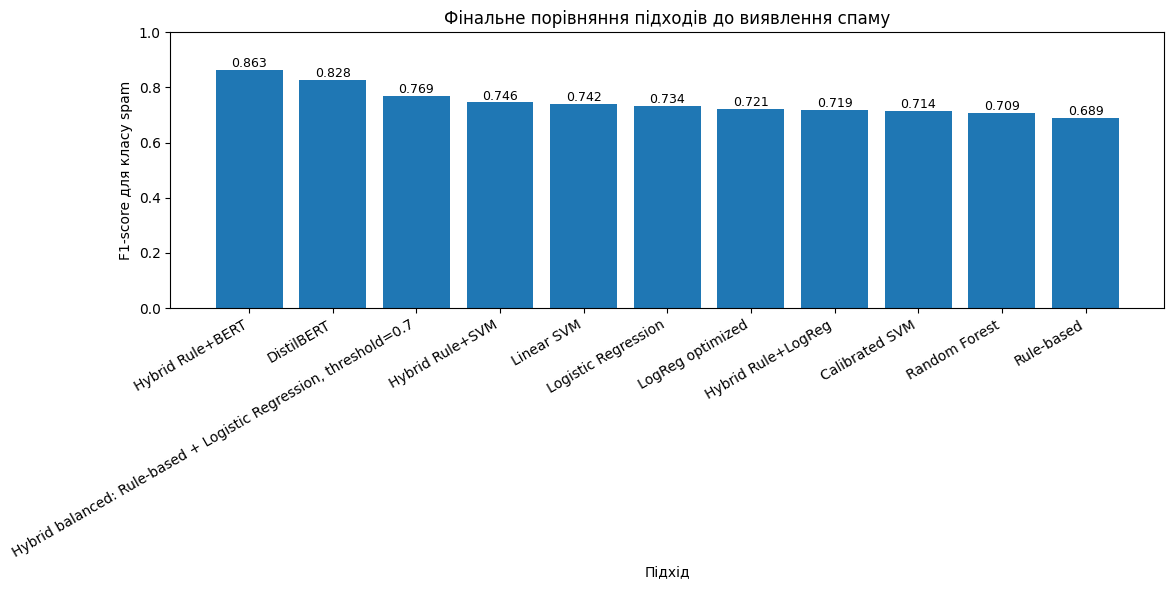

In [148]:
final_plot_df = final_comparison_df.copy()

def shorten_model_name(model_name):
    if model_name.startswith("Hybrid: Rule-based + BERT"):
        return "Hybrid Rule+BERT"
    elif model_name.startswith("BERT / DistilBERT multilingual"):
        return "DistilBERT"
    elif model_name.startswith("Hybrid balanced: Rule-based + ML"):
        return "Hybrid Rule+ML"
    elif model_name.startswith("Hybrid: Rule-based + Calibrated SVM"):
        return "Hybrid Rule+SVM"
    elif model_name.startswith("ML: Linear SVM"):
        return "Linear SVM"
    elif model_name.startswith("ML: Logistic Regression optimized"):
        return "LogReg optimized"
    elif model_name.startswith("ML: Logistic Regression"):
        return "Logistic Regression"
    elif model_name.startswith("Hybrid: Rule-based + Logistic Regression"):
        return "Hybrid Rule+LogReg"
    elif model_name.startswith("ML: Calibrated Linear SVM"):
        return "Calibrated SVM"
    elif model_name.startswith("ML: Random Forest"):
        return "Random Forest"
    elif model_name.startswith("Rule-based"):
        return "Rule-based"
    else:
        return model_name

final_plot_df["short_model"] = final_plot_df["model"].apply(shorten_model_name)

final_plot_df = final_plot_df.sort_values(
    by="f1_spam",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(12, 6))

plt.bar(
    final_plot_df["short_model"],
    final_plot_df["f1_spam"]
)

plt.xlabel("Підхід")
plt.ylabel("F1-score для класу spam")
plt.title("Фінальне порівняння підходів до виявлення спаму")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

for index, value in enumerate(final_plot_df["f1_spam"]):
    plt.text(
        index,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Збереження результатів BERT**

In [129]:
BERT_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "bert_predictions.csv"
)

bert_results = test_df.copy()
bert_results["bert_spam_probability"] = bert_spam_probability
bert_results["predicted_label_bert"] = y_pred_bert
bert_results["bert_hybrid_score"] = test_bert_hybrid_score
bert_results["predicted_label_bert_hybrid"] = y_pred_bert_hybrid

bert_results.to_csv(
    BERT_RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Результати BERT збережено:")
print(BERT_RESULTS_PATH)

Результати BERT збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/bert_predictions.csv


In [130]:
BERT_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "bert_metrics.csv"
)

bert_comparison_df.to_csv(
    BERT_METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Метрики BERT збережено:")
print(BERT_METRICS_PATH)

Метрики BERT збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/bert_metrics.csv


In [131]:
FINAL_COMPARISON_PATH = os.path.join(
    RESULTS_DIR,
    "final_model_comparison.csv"
)

final_comparison_df.to_csv(
    FINAL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Фінальне порівняння моделей збережено:")
print(FINAL_COMPARISON_PATH)

Фінальне порівняння моделей збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/final_model_comparison.csv


**Збереження BERT-моделі**

In [132]:
FINAL_BERT_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "bert_spam_final"
)

trainer.save_model(FINAL_BERT_MODEL_PATH)
tokenizer.save_pretrained(FINAL_BERT_MODEL_PATH)

print("BERT-модель збережено:")
print(FINAL_BERT_MODEL_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT-модель збережено:
/content/drive/MyDrive/telegram_spam_diploma/models/bert_spam_final


##Аналіз помилок та фінальна логіка антиспам-системи

**Формування результатів найкращої моделі**

In [133]:
best_model_results = test_df.copy()

best_model_results["bert_spam_probability"] = bert_spam_probability
best_model_results["rule_score"] = test_df["preliminary_spam_score"].values
best_model_results["rule_score_normalized"] = test_rule_score_normalized
best_model_results["hybrid_bert_score"] = test_bert_hybrid_score
best_model_results["true_label"] = y_test_bert
best_model_results["predicted_label"] = y_pred_bert_hybrid

best_model_results["prediction_type"] = best_model_results.apply(
    lambda row: (
        "true_positive" if row["true_label"] == 1 and row["predicted_label"] == 1 else
        "true_negative" if row["true_label"] == 0 and row["predicted_label"] == 0 else
        "false_positive" if row["true_label"] == 0 and row["predicted_label"] == 1 else
        "false_negative"
    ),
    axis=1
)

best_model_results[[
    "clean_text",
    "true_label",
    "predicted_label",
    "prediction_type",
    "rule_score",
    "bert_spam_probability",
    "hybrid_bert_score"
]].head()

,clean_text,true_label,predicted_label,prediction_type,rule_score,bert_spam_probability,hybrid_bert_score
0,"🤯 Будинок на Столичному шосе, де [чоловік на гранаті підірвався](https://t.me/kievinfo_kyiv/88354), знову почав горіти, 3:04** **[ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний...",0,0,true_negative,4,0.015366,0.169220
1,"**⚡️У 333 рази зросла кількість звернень щодо порушень прав громадян України, пов'язаних з проведенням мобілізації, у порівнянні з 2022 роком, – **Лубінець вимагає термінового створення робочої гр...",0,0,true_negative,5,0.012829,0.207697
2,**Засновнику Celsius заборонили працювати у криптосекторі довічно ** Суд США [затвердив](https://incrypted.com/ua/zasnovnyk-celsius-otrymav-dovichnu-zaboronu/) угоду з екс-керівником Celsius Алекс...,0,0,true_negative,7,0.013381,0.288028
3,**🇺🇦 Силовики лідирують за кількістю криптовалюти серед чиновників** Історія з [декларацією співробітника ТЦК](https://t.me/incrypted_UA/15504) — не поодинокий випадок. Аналіз за 2025 рік [показує...,0,0,true_negative,3,0.012603,0.127562
4,"**Чи готові ви обманути ціле королівство, надягнувши чужу маску, щоб врятувати того, кого любите?❤️‍🩹** Саме перед таким вибором постає головна героїня. І вже в цю мить я зрозуміла: мене точно чек...",0,0,true_negative,7,0.011677,0.287006


**Кількість типів прогнозів**

In [134]:
best_model_results["prediction_type"].value_counts()

,count
prediction_type,
true_negative,186
true_positive,41
false_negative,9
false_positive,4


**False positives**

In [135]:
false_positives = best_model_results[
    best_model_results["prediction_type"] == "false_positive"
].copy()

print("Кількість false positives:", len(false_positives))

false_positives[[
    "clean_text",
    "source" if "source" in false_positives.columns else "true_label",
    "rule_score",
    "bert_spam_probability",
    "hybrid_bert_score"
]].head(10)

Кількість false positives: 4


,clean_text,true_label,rule_score,bert_spam_probability,hybrid_bert_score
132,**❌ Meta звільнить 8000 співробітників заради ШІ** Компанія Meta [готує](https://incrypted.com/ua/%d0%b7%d0%bc%d1%96-meta-%d0%b7%d0%b2%d1%96%d0%bb%d1%8c%d0%bd%d0%b8%d1%82%d1%8c-%d1%89%d0%b5-8000-%...,0,5,0.986645,0.791987
143,"**Weekly: біткоїн перевищив позначку $78 000, квантова загроза та майже $4 млрд збитків BitMine** https://incrypted.com/ua/weekly-bitkoyin-vishe-78-000-kvantova-zagroza-ta-majzhe-4-mlrd-zbitkiv-bi...",0,5,0.983146,0.789888
191,"🪙** Як ситуація в Ормузькій протоці може вплинути на біткойн ** Якщо Іран [почне](https://x.com/cevenif/status/2042146955808362627) стягувати плату за прохід танкерів у біткоїнах, ринок може отрим...",0,5,0.975356,0.785213
215,**📣 Підвищення цін на Incrypted Conference 2026 уже скоро!** З 00:00 1 травня вартість квитків зросте: - VIP: $250 → $300 - Regular: $80 → $100 Якщо ви відкладали покупку — поспішайте зафіксувати ...,0,5,0.984387,0.790632


**False negatives**

In [136]:
false_negatives = best_model_results[
    best_model_results["prediction_type"] == "false_negative"
].copy()

print("Кількість false negatives:", len(false_negatives))

false_negatives[[
    "clean_text",
    "rule_score",
    "bert_spam_probability",
    "hybrid_bert_score"
]].head(10)

Кількість false negatives: 9


,clean_text,rule_score,bert_spam_probability,hybrid_bert_score
7,**CEO Cardano розкритикував план захисту біткоїна від квантових атак ** Засновник Cardano Чарльз Хоскінсон [заявив](https://incrypted.com/ua/zasnovnyk-cardano-rozkrytykuvav-plan-zahystu-merezhi-bi...,5,0.017038,0.210223
46,"**CEO ARK Invest: падіння BTC на 50% — це вже «перемога»** CEO ARK Invest Кеті Вуд [заявила](https://incrypted.com/ua/ceo-ark-invest-nazvala-padinnja-bitkojina-na-50-spravzhnoju-peremogoju/), що п...",5,0.086491,0.251894
53,**🇪🇺 ЄС запровадив криптообмеження проти РФ у новому пакеті санкцій ** Євросоюз [включив](https://incrypted.com/ua/yes-zaboroniv-kriptooperaciyi-z-rosijskimi-servisami-v-mezhah-20-go-paketa-sankci...,5,0.014355,0.208613
140,**Фармимо-поінти в GRVT** [GRVT](https://grvt.io/?ref=INCRYPTED) продовжує зміцнювати свої позиції в топ-рейтингу децентралізованих бірж. На сьогодні платформа посідає лідерські позиції серед усіх...,17,0.046029,0.427618
145,"🐈 ЧОМУ СЕКС-ІГРАШКИ — ЦЕ НЕ РОЗКІШ, А НЕОБХІДНІСТЬ 💋 70% жінок не досягають оргазму без додаткової стимуляції. 💋 80% пар зізнаються, що рутина в ліжку — причина втрати бажання. 💋 Секс-іграшки покр...",7,0.028708,0.297225
149,**Скамери використовують «новини про війну» для шахрайства у криптовалютній сфері** Ончейн-детектив ZachXBT [виявив](https://incrypted.com/ua/zachxbt-vykryv-merezhu-akauntiv-z-fejkamy-pro-vijnu-dl...,9,0.016400,0.369840
160,"**🇺🇸 CFTC дала «зелене світло» ринкам прогнозів у США ** Американський регулятор [заявив](https://incrypted.com/ua/cftc-dala-zelene-svitlo-rynkam-prognoziv-u-ssha/), що не буде переслідувати платф...",7,0.024058,0.294435
168,"**🌚 Хейс: BTC зросте завдяки «друкарському верстату», а 99% альткоїнів зникнуть** На Consensus Miami 2026 колишній гендиректор BitMEX Артур Хейс [заявив](https://incrypted.com/ua/artur-hejs-na-con...",11,0.040893,0.424536
182,**Квантова загроза для BTC — міф чи реальність?** Galaxy Digital [заявила](https://incrypted.com/ua/u-galaxy-digital-otsinyly-ryzyky-kvantovyh-komp-juteriv-dlja-bitkojina-ta-gotovnist-industriji/)...,5,0.032299,0.219379


**Правильно знайдений спам**

In [137]:
true_positives = best_model_results[
    best_model_results["prediction_type"] == "true_positive"
].copy()

print("Кількість true positives:", len(true_positives))

true_positives[[
    "clean_text",
    "rule_score",
    "bert_spam_probability",
    "hybrid_bert_score"
]].head(10)

Кількість true positives: 41


,clean_text,rule_score,bert_spam_probability,hybrid_bert_score
26,"**🐳 «Продамо 1 BTC — купимо ще 10»** Ексглава Strategy Майкл Сейлор [пояснив](https://x.com/saylor/status/2053225568871780548?s=20), чому можливий продаж частини BTC з боку компанії — не привід дл...",9,0.921943,0.913166
31,**⛏️ Соло-майнер видобув блок біткоїна і заробив ~$210 000 ** Соло-майнер самотужки [знайшов](https://incrypted.com/ua/solo-majner-bitkoyina-dobuv-blok-i-otrimav-blizko-210-000-vinagorodi/) блок №...,5,0.943238,0.765943
35,"📌Усі, хто **не отримав нагороду** з даної роздачі, потрібно **заповнити** цю 👉[**форму**](https://forms.gle/VqYzMtrqoD6g9k1Q9)👈 для того, щоб вони перевірили ваш акаунт на активність та виконання ...",3,0.986391,0.711834
38,📌 **О**НОВЛЕНИЙ ТОП АКТУАЛЬНИХ СХЕМ БЕЗ ВКЛАДЕНЬ НА ДАНИЙ МОМЕНТ 🤑 🔥__Особливо рекомендую виконати схеми з відміткою __**VIP** 😀 1️⃣ 😀 **Отримуємо 150 грн за реєстрацію та 150 грн за запрошення др...,16,0.985576,0.991345
41,**▶️**** DreamCash — новий DEX на Hyperliquid із поінтами та можливим дропом ** https://youtu.be/15-HfDdKLHQ На [нашому Youtube-каналі ](https://www.youtube.com/@Incryptednet)вийшов детальний розб...,5,0.980419,0.788251
42,"🤑**ВЖЕ ЗАРОБИВ****➕****4000 ГРИВЕНЬ НА ЦІЙ СХЕМІ БЕЗ ВКЛАДЕНЬ**👨‍💻 ❗️**__Встигніть забрати безкоштовні 200 гривень БЕЗ ВКЛАДЕНЬ__ **🤯 🎁Акція діє до **31 серпня**, але як це часто буває, може завер...",8,0.984871,0.910923
44,"😱**Напевне уже всі чули, що можна заробляти просто за те, що ви ходите** 🏃 📲Так от **Sweatcoin** - це якраз той додаток на якому можна буде заробити, запустили його уже досить давно і багато хто н...",12,0.985374,0.991224
45,**GM!** - BTC ≈$78 100 (+0.74%) - ETH ≈$2 330 (+0.67%) - SOL ≈$87 (+0.47%) - Капіталізація ринку ≈$2.6T (+0.40%) - Індекс страху і жадібності: 45 (Нейтральний) - Індекс альтсезону: 39 Детальніше в...,9,0.987752,0.952651
47,**▶️**** Не переглянули наше відео? Фатальна помилка** https://youtu.be/r3EtHEGS_24 Під цим відео☝️зібралося багато позитивних коментарів від глядачів — частину з них ми зібрали на зображенні вище...,7,0.984053,0.870432
54,🤑**Роздача 5$ в токені PHL за реєстрацію та KYC + 5$ за друга від PhilCoin (Депозит робити НЕ потрібно)🔥** 📌Токен **__PHL__** який ми отримаємо в цій роздачі торгується на [біржі MEXC](https://www...,10,0.989367,0.993620


**Рішення системи за рівнем ризику**

In [138]:
def assign_system_action(score):
    if score < 0.30:
        return "allow"
    elif score < 0.50:
        return "soft_warning"
    elif score < 0.70:
        return "send_to_review"
    elif score < 0.85:
        return "delete_message"
    else:
        return "temporary_restrict"

In [139]:
best_model_results["system_action"] = best_model_results["hybrid_bert_score"].apply(
    assign_system_action
)

best_model_results[[
    "clean_text",
    "true_label",
    "predicted_label",
    "hybrid_bert_score",
    "system_action"
]].head(20)

,clean_text,true_label,predicted_label,hybrid_bert_score,system_action
0,"🤯 Будинок на Столичному шосе, де [чоловік на гранаті підірвався](https://t.me/kievinfo_kyiv/88354), знову почав горіти, 3:04** **[ㅤ](https://t.me/+aAaZ8kQkkpo2ZjRi) **Надсилайте новини в анонімний...",0,0,0.169220,allow
1,"**⚡️У 333 рази зросла кількість звернень щодо порушень прав громадян України, пов'язаних з проведенням мобілізації, у порівнянні з 2022 роком, – **Лубінець вимагає термінового створення робочої гр...",0,0,0.207697,allow
2,**Засновнику Celsius заборонили працювати у криптосекторі довічно ** Суд США [затвердив](https://incrypted.com/ua/zasnovnyk-celsius-otrymav-dovichnu-zaboronu/) угоду з екс-керівником Celsius Алекс...,0,0,0.288028,allow
3,**🇺🇦 Силовики лідирують за кількістю криптовалюти серед чиновників** Історія з [декларацією співробітника ТЦК](https://t.me/incrypted_UA/15504) — не поодинокий випадок. Аналіз за 2025 рік [показує...,0,0,0.127562,allow
4,"**Чи готові ви обманути ціле королівство, надягнувши чужу маску, щоб врятувати того, кого любите?❤️‍🩹** Саме перед таким вибором постає головна героїня. І вже в цю мить я зрозуміла: мене точно чек...",0,0,0.287006,allow
5,🔴🔴🔴⚠️** Загроза балістики **🚀**з Курська **💥 В укриття!,0,0,0.047854,allow
6,🔵 **Підготовчі курси до Єдиного вступного іспиту в магістратуру від КПІ** ! 📖 На слухачів наших підготовчих курсів з 🇬🇧**АНГЛІЙСЬКОЇ МОВИ** очікує: ▫️ досвідчені викладачі університету; ▫️ індивід...,0,0,0.288414,allow
7,**CEO Cardano розкритикував план захисту біткоїна від квантових атак ** Засновник Cardano Чарльз Хоскінсон [заявив](https://incrypted.com/ua/zasnovnyk-cardano-rozkrytykuvav-plan-zahystu-merezhi-bi...,1,0,0.210223,allow
8,**ШІ-агенти та блокчейн: навіщо відвідувати хакатон Mantle** https://incrypted.com/ua/navishcho-rozrobnykam-braty-uchast-u-novomu-onlajn-hakatoni-vid-mantle/ ШІ в крипті перестає бути просто інстр...,0,0,0.335293,soft_warning
9,Погоджуюсь. Ця інформація досить актуальна.,0,0,0.008800,allow


**Розподіл рішень системи**

In [140]:
action_counts = best_model_results["system_action"].value_counts().reset_index()
action_counts.columns = ["system_action", "count"]

action_counts

,system_action,count
0,allow,174
1,temporary_restrict,28
2,soft_warning,18
3,delete_message,17
4,send_to_review,3


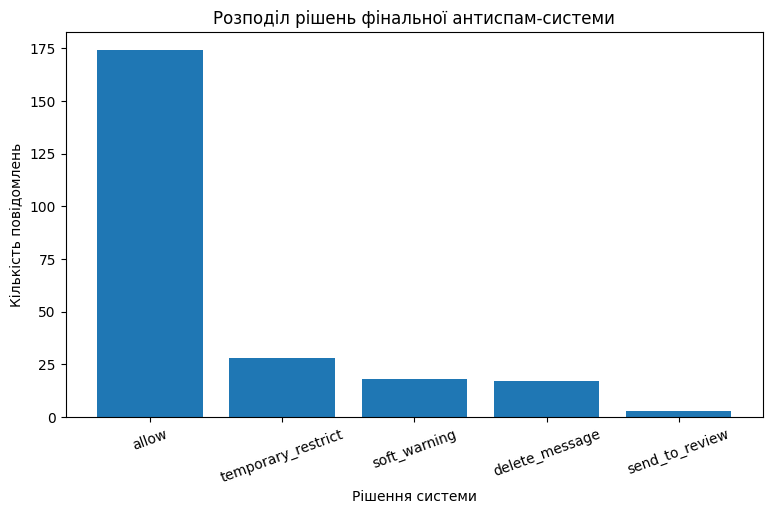

In [141]:
plt.figure(figsize=(9, 5))
plt.bar(action_counts["system_action"], action_counts["count"])
plt.xlabel("Рішення системи")
plt.ylabel("Кількість повідомлень")
plt.title("Розподіл рішень фінальної антиспам-системи")
plt.xticks(rotation=20)
plt.show()

**Збереження аналізу помилок**

In [142]:
ERROR_ANALYSIS_PATH = os.path.join(
    RESULTS_DIR,
    "final_error_analysis_hybrid_bert.csv"
)

best_model_results.to_csv(
    ERROR_ANALYSIS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Аналіз помилок фінальної моделі збережено:")
print(ERROR_ANALYSIS_PATH)

Аналіз помилок фінальної моделі збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/final_error_analysis_hybrid_bert.csv


**Окреме збереження false positives / false negatives**

In [143]:
FALSE_POSITIVES_PATH = os.path.join(
    RESULTS_DIR,
    "false_positives_hybrid_bert.csv"
)

FALSE_NEGATIVES_PATH = os.path.join(
    RESULTS_DIR,
    "false_negatives_hybrid_bert.csv"
)

false_positives.to_csv(
    FALSE_POSITIVES_PATH,
    index=False,
    encoding="utf-8-sig"
)

false_negatives.to_csv(
    FALSE_NEGATIVES_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("False positives збережено:")
print(FALSE_POSITIVES_PATH)

print("\nFalse negatives збережено:")
print(FALSE_NEGATIVES_PATH)

False positives збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/false_positives_hybrid_bert.csv

False negatives збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/false_negatives_hybrid_bert.csv


##Підготовка фінальної антиспам-системи до інтеграції з Telegram-ботом

**Збереження фінальної DistilBERT-моделі**

Найкращий результат показала модель:

Hybrid: Rule-based + DistilBERT

Тому зберігаємо навчену DistilBERT-модель і токенізатор.

In [149]:
FINAL_BERT_MODEL_PATH = os.path.join(
    MODELS_DIR,
    "bert_spam_final"
)

trainer.save_model(FINAL_BERT_MODEL_PATH)
tokenizer.save_pretrained(FINAL_BERT_MODEL_PATH)

print("Фінальну DistilBERT-модель збережено:")
print(FINAL_BERT_MODEL_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Фінальну DistilBERT-модель збережено:
/content/drive/MyDrive/telegram_spam_diploma/models/bert_spam_final


**Збереження параметрів гібридної моделі**

In [150]:
import json

HYBRID_BERT_CONFIG = {
    "model_type": "Hybrid Rule-based + DistilBERT",
    "bert_model_path": "bert_spam_final",
    "alpha": float(BEST_BERT_ALPHA),
    "beta": float(BEST_BERT_BETA),
    "threshold": float(BEST_BERT_HYBRID_THRESHOLD),
    "rule_score_normalization_divisor": 10,
    "class_0": "not_spam",
    "class_1": "spam"
}

HYBRID_CONFIG_PATH = os.path.join(
    MODELS_DIR,
    "hybrid_bert_config.json"
)

with open(HYBRID_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(
        HYBRID_BERT_CONFIG,
        f,
        ensure_ascii=False,
        indent=4
    )

print("Конфігурацію найкращої гібридної моделі збережено:")
print(HYBRID_CONFIG_PATH)

HYBRID_BERT_CONFIG

Конфігурацію найкращої гібридної моделі збережено:
/content/drive/MyDrive/telegram_spam_diploma/models/hybrid_bert_config.json


{'model_type': 'Hybrid Rule-based + DistilBERT',
 'bert_model_path': 'bert_spam_final',
 'alpha': 0.6,
 'beta': 0.4,
 'threshold': 0.7,
 'rule_score_normalization_divisor': 10,
 'class_0': 'not_spam',
 'class_1': 'spam'}

**Перевірка наявності збережених файлів**

In [151]:
print("Файли у папці MODELS_DIR:")
print(os.listdir(MODELS_DIR))

print("\nФайли у папці bert_spam_final:")
print(os.listdir(FINAL_BERT_MODEL_PATH))

Файли у папці MODELS_DIR:
['best_ml_model.pkl', 'bert_spam_model', 'bert_spam_final', 'logistic_regression_for_hybrid.pkl', 'hybrid_bert_config.json']

Файли у папці bert_spam_final:
['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json']


**Фінальна функція перевірки нового повідомлення**

Ця функція використовує вже навчену модель, rule-based score і параметри найкращої гібридної моделі.

In [152]:
def get_bert_spam_probability(text):
    text = str(text)

    inputs = tokenizer(
        text,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(trainer.model.device)
        for key, value in inputs.items()
    }

    trainer.model.eval()

    with torch.no_grad():
        outputs = trainer.model(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)

    spam_probability = probabilities[0][1].item()

    return spam_probability

In [153]:
def extract_single_message_features(text, has_media=0, views=0, forwards=0):
    text = str(text)

    features = {
        "text": text,
        "message_length": len(text),
        "url_count": count_urls(text),
        "trigger_word_count": count_trigger_words(text, SPAM_TRIGGER_WORDS),
        "cta_word_count": count_trigger_words(text, CTA_WORDS),
        "finance_word_count": count_trigger_words(text, FINANCE_WORDS),
        "exclamation_count": count_exclamation_marks(text),
        "caps_ratio": caps_ratio(text),
        "emoji_count": count_emojis_simple(text),
        "has_media": has_media,
        "views": views,
        "forwards": forwards
    }

    return features

In [154]:
def calculate_single_rule_score(features):
    score = 0

    if features["url_count"] > 0:
        score += 2

    if features["trigger_word_count"] > 0:
        score += features["trigger_word_count"] * 2

    if features["cta_word_count"] > 0:
        score += features["cta_word_count"]

    if features["finance_word_count"] > 0:
        score += features["finance_word_count"] * 2

    if features["exclamation_count"] >= 3:
        score += 1

    if features["caps_ratio"] > 0.5 and features["message_length"] > 15:
        score += 2

    if features["emoji_count"] >= 3:
        score += 1

    if features["has_media"] == 1 and features["url_count"] > 0:
        score += 1

    return score

In [155]:
def predict_telegram_message_spam(text, has_media=0, views=0, forwards=0):
    features = extract_single_message_features(
        text=text,
        has_media=has_media,
        views=views,
        forwards=forwards
    )

    rule_score = calculate_single_rule_score(features)
    rule_score_normalized = min(rule_score / 10, 1)

    bert_spam_probability = get_bert_spam_probability(text)

    hybrid_score = (
        BEST_BERT_ALPHA * bert_spam_probability +
        BEST_BERT_BETA * rule_score_normalized
    )

    predicted_label = int(hybrid_score >= BEST_BERT_HYBRID_THRESHOLD)

    result = {
        "text": text,
        "rule_score": rule_score,
        "rule_score_normalized": rule_score_normalized,
        "bert_spam_probability": bert_spam_probability,
        "hybrid_score": hybrid_score,
        "threshold": BEST_BERT_HYBRID_THRESHOLD,
        "predicted_label": predicted_label,
        "predicted_class": "spam" if predicted_label == 1 else "not_spam",
        "system_action": assign_system_action(hybrid_score),
        "features": features
    }

    return result

**Тестування фінальної системи на нових повідомленнях**

In [168]:
example_messages = [

    "Привіт, завтра буде пара з програмування о 10:25",
    "Вітаю! Надсилаю матеріали до лабораторної роботи, перегляньте файл до заняття.",
    "Новий матеріал уже доступний на сайті кафедри, перегляньте інформацію перед практичною.",
    "🔥🔥🔥 КАЗИНО БОНУС 10000 ГРН!!! Забирай подарунок прямо зараз! Реєструйся за посиланням http://casino-bonus-example.com і отримай промокод!",
    "💰 Заробляй від 3000 грн на день без досвіду! Швидкі виплати, пасивний дохід, прибуток щодня. Пиши в особисті повідомлення або переходь t.me/money_bonus",
    "🎁 ТІЛЬКИ СЬОГОДНІ! Безкоштовний бонус за реєстрацію, промокод, виграш гарантовано! Натисни на посилання та забирай подарунок http://free-gift-example.com",
    "VIP СТАВКИ НА СПОРТ 💸 bet, casino, crypto, usdt, швидкий прибуток! Приєднуйся зараз до каналу t.me/vip_bet_signals і отримай гарантований дохід!",
    "🚀 Крипта росте! Інвестуй 500 грн і отримай 5000 грн прибутку вже сьогодні. Без досвіду, без ризику, швидкі виплати на карту. Переходь t.me/crypto_income",
    "АКЦІЯ!!! Отримай 7000 грн бонусу за реєстрацію! Залишилось мало місць, тисни на посилання, забирай виграш і подарунок зараз http://bonus-example.com",
    "💵 Робота онлайн без досвіду! Заробіток, дохід, виплати щодня, потрібен тільки телефон. Напиши мені зараз і отримай інструкцію t.me/easy_money"
]

demo_results = []

for message in example_messages:
    result = predict_telegram_message_spam(message)
    demo_results.append(result)

    print("=" * 100)
    print("Текст:", result["text"])
    print("Rule score:", result["rule_score"])
    print("Rule score normalized:", round(result["rule_score_normalized"], 4))
    print("BERT spam probability:", round(result["bert_spam_probability"], 4))
    print("Hybrid score:", round(result["hybrid_score"], 4))
    print("Threshold:", result["threshold"])
    print("Predicted class:", result["predicted_class"])
    print("System action:", result["system_action"])

Текст: Привіт, завтра буде пара з програмування о 10:25
Rule score: 0
Rule score normalized: 0.0
BERT spam probability: 0.2378
Hybrid score: 0.1427
Threshold: 0.7
Predicted class: not_spam
System action: allow
Текст: Вітаю! Надсилаю матеріали до лабораторної роботи, перегляньте файл до заняття.
Rule score: 0
Rule score normalized: 0.0
BERT spam probability: 0.0116
Hybrid score: 0.0069
Threshold: 0.7
Predicted class: not_spam
System action: allow
Текст: Новий матеріал уже доступний на сайті кафедри, перегляньте інформацію перед практичною.
Rule score: 0
Rule score normalized: 0.0
BERT spam probability: 0.0172
Hybrid score: 0.0103
Threshold: 0.7
Predicted class: not_spam
System action: allow
Текст: 🔥🔥🔥 КАЗИНО БОНУС 10000 ГРН!!! Забирай подарунок прямо зараз! Реєструйся за посиланням http://casino-bonus-example.com і отримай промокод!
Rule score: 20
Rule score normalized: 1
BERT spam probability: 0.0311
Hybrid score: 0.4187
Threshold: 0.7
Predicted class: not_spam
System action: soft_warn

**Збереження демонстраційних результатів**

In [169]:
DEMO_RESULTS_PATH = os.path.join(
    RESULTS_DIR,
    "demo_final_system_predictions.csv"
)

demo_results_df.to_csv(
    DEMO_RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Демонстраційні результати фінальної системи збережено:")
print(DEMO_RESULTS_PATH)

Демонстраційні результати фінальної системи збережено:
/content/drive/MyDrive/telegram_spam_diploma/results/demo_final_system_predictions.csv
